# CV Halo FD Jacobian: Scatter-Notebook Statistics — Parameter Derivatives

Finite-difference Jacobians of all 35 per-halo morphological statistics
(from `scatter.ipynb`) and 15 population-level scaling-relation statistics
with respect to all 35 CAMELS cosmological + astrophysical parameters.

Loaded from: `analysis_physics_cache/proj6_cv_fd_scatter_fm_two_head.npz`


## Imports & Configuration

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')

ROOT      = Path('/mnt/home/mlee1/vdm_bind2')
CACHE_DIR = ROOT / 'analysis_physics_cache'
CV_FD_CACHE = CACHE_DIR / 'proj6_cv_fd_scatter_fm_two_head.npz'
FM_RUN_DIR  = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
CV_ROOT     = Path('/mnt/home/mlee1/ceph/fm_testsuite/CV')
SIM_SUBPATH = 'snap_090/mass_threshold_1p000e13'
N_PARAMS = 35

# ── CAMELS parameter pretty-print labels ─────────────────────────────────────
PRETTY = {
    0:  r'$\Omega_m$',       1:  r'$\sigma_8$',          2:  r'$A_{\rm SN1}$',
    3:  r'$A_{\rm AGN1}$',   4:  r'$A_{\rm SN2}$',       5:  r'$A_{\rm AGN2}$',
    6:  r'$\Omega_b$',       7:  r'$h$',                   8:  r'$n_s$',
    9:  r'$w_0$',             10: r'$w_a$',                 11: r'$M_\nu$',
    12: r'$\alpha_{\rm SF}$', 13: r'$\beta_{\rm SF}$', 14: r'$\rho_{\rm wind}$',
    15: r'$M_{\rm SNII}$',   16: r'$\eta_w$',             17: r'$E_{\rm SN}$',
    18: r'$\epsilon_r$',     19: r'$M_{\rm seed}$',       20: r'$\alpha_{\rm acc}$',
    21: r'$\beta_{\rm acc}$', 22: r'$M_{\rm fof}$',     23: r'$V_{\rm Bh}$',
    24: r'$\alpha_{w,{\rm SN}}$', 25: r'$\tau_{\rm BH}$', 26: r'$p_{\rm wind}$',
    27: r'$v_{\rm kick}$',   28: r'$\alpha_{w,Z}$',       29: r'$R_{\rm trunc}$',
    30: r'$\beta_{\rm UV}$', 31: r'$\alpha_{\rm UV}$', 32: r'$\beta_{\rm HeII}$',
    33: r'$T_{\rm reion}$',  34: r'$z_{\rm reion}$',
}
PARAM_GROUP = {
    0:'cosmo', 1:'cosmo', 2:'SN',    3:'AGN',   4:'SN',    5:'AGN',
    6:'cosmo', 7:'cosmo', 8:'cosmo', 9:'cosmo', 10:'cosmo',11:'cosmo',
    12:'SN',   13:'SN',   14:'SN',   15:'SN',   16:'SN',   17:'SN',
    18:'AGN',  19:'AGN',  20:'AGN',  21:'AGN',  22:'AGN',  23:'AGN',
    24:'SN',   25:'AGN',  26:'SN',   27:'SN',   28:'SN',   29:'other',
    30:'other',31:'other',32:'other',33:'other', 34:'other',
}
GROUP_COLORS = {'cosmo':'#1E88E5','SN':'#FF8F00','AGN':'#E53935','other':'#757575'}

# ── Per-halo and population observable keys ───────────────────────────────────
PER_HALO_KEYS = [
    "M_dm","M_gas","M_star","M_bar",
    "f_bar","f_gas","f_star",
    "q_dm_R","q_gas_R","q_star_R",
    "q_dm_h","q_gas_h","q_star_h",
    "e1_dm","e1_gas","e1_star","e2_dm","e2_gas","e2_star",
    "conc_dm","conc_gas","conc_star",
    "rhalf_dm","rhalf_gas","rhalf_star",
    "cent4_dm","cent4_gas","cent4_star",
    "peak_dm","peak_gas","peak_star",
    "dtheta_dg","dtheta_ds","dtheta_gs",
    "dq_dm",
]
POP_KEYS = [
    "alpha_MgMs","beta_MgMs","sigma_MgMs",
    "alpha_MdMs","beta_MdMs","sigma_MdMs",
    "alpha_SHMR", "beta_SHMR", "sigma_SHMR",
    "alpha_GasFr","beta_GasFr","sigma_GasFr",
    "alpha_BarFr","beta_BarFr","sigma_BarFr",
]
KEY_GROUPS = {
    'masses':    ["M_dm","M_gas","M_star","M_bar"],
    'fractions': ["f_bar","f_gas","f_star"],
    'q_R':       ["q_dm_R","q_gas_R","q_star_R"],
    'q_h':       ["q_dm_h","q_gas_h","q_star_h"],
    'ellip':     ["e1_dm","e1_gas","e1_star","e2_dm","e2_gas","e2_star"],
    'conc_rhalf':["conc_dm","conc_gas","conc_star","rhalf_dm","rhalf_gas","rhalf_star"],
    'central':   ["cent4_dm","cent4_gas","cent4_star","peak_dm","peak_gas","peak_star"],
    'misalign':  ["dtheta_dg","dtheta_ds","dtheta_gs","dq_dm"],
}
KEY_LATEX = {
    "M_dm":     r'$M_{\rm DM}$',        "M_gas":    r'$M_{\rm gas}$',
    "M_star":   r'$M_\star$',            "M_bar":    r'$M_{\rm bar}$',
    "f_bar":    r'$f_{\rm bar}$',        "f_gas":    r'$f_{\rm gas}$',
    "f_star":   r'$f_\star$',
    "q_dm_R":   r'$q_{\rm DM}(R)$',     "q_gas_R":  r'$q_{\rm gas}(R)$',
    "q_star_R": r'$q_\star(R)$',
    "q_dm_h":   r'$q_{\rm DM}(R/2)$',   "q_gas_h":  r'$q_{\rm gas}(R/2)$',
    "q_star_h": r'$q_\star(R/2)$',
    "e1_dm":    r'$e_{1,\rm DM}$',       "e1_gas":   r'$e_{1,\rm gas}$',
    "e1_star":  r'$e_{1,\star}$',        "e2_dm":    r'$e_{2,\rm DM}$',
    "e2_gas":   r'$e_{2,\rm gas}$',      "e2_star":  r'$e_{2,\star}$',
    "conc_dm":  r'$c_{\rm DM}$',         "conc_gas": r'$c_{\rm gas}$',
    "conc_star":r'$c_\star$',
    "rhalf_dm": r'$r_{1/2,\rm DM}/R$',   "rhalf_gas":r'$r_{1/2,\rm gas}/R$',
    "rhalf_star":r'$r_{1/2,\star}/R$',
    "cent4_dm": r'$\rho_{4,\rm DM}$',   "cent4_gas":r'$\rho_{4,\rm gas}$',
    "cent4_star":r'$\rho_{4,\star}$',
    "peak_dm":  r'$\rho_{\rm pk,DM}$',  "peak_gas": r'$\rho_{\rm pk,gas}$',
    "peak_star":r'$\rho_{\rm pk,\star}$',
    "dtheta_dg":r'$\Delta\theta_{\rm DG}$',  "dtheta_ds":r'$\Delta\theta_{\rm DS}$',
    "dtheta_gs":r'$\Delta\theta_{\rm GS}$',  "dq_dm":    r'$\Delta q_{\rm DM}$',
}
POP_LATEX = {
    "alpha_MgMs": r'$\alpha(M_{\rm g}$-$M_\star)$',
    "beta_MgMs":  r'$\beta(M_{\rm g}$-$M_\star)$',
    "sigma_MgMs": r'$\sigma(M_{\rm g}$-$M_\star)$',
    "alpha_MdMs": r'$\alpha(M_{\rm d}$-$M_\star)$',
    "beta_MdMs":  r'$\beta(M_{\rm d}$-$M_\star)$',
    "sigma_MdMs": r'$\sigma(M_{\rm d}$-$M_\star)$',
    "alpha_SHMR":  r'$\alpha_{\rm SHMR}$',
    "beta_SHMR":   r'$\beta_{\rm SHMR}$',
    "sigma_SHMR":  r'$\sigma_{\rm SHMR}$',
    "alpha_GasFr": r'$\alpha(M_{\rm g}$-$M_{200})$',
    "beta_GasFr":  r'$\beta(M_{\rm g}$-$M_{200})$',
    "sigma_GasFr": r'$\sigma(M_{\rm g}$-$M_{200})$',
    "alpha_BarFr": r'$\alpha(M_{\rm b}$-$M_{200})$',
    "beta_BarFr":  r'$\beta(M_{\rm b}$-$M_{200})$',
    "sigma_BarFr": r'$\sigma(M_{\rm b}$-$M_{200})$',
}
# Observables that are positive-definite (can take log10 for elasticity view)
LOG_POS_KEYS = frozenset([
    "M_dm","M_gas","M_star","M_bar","f_bar","f_gas","f_star",
    "conc_dm","conc_gas","conc_star","rhalf_dm","rhalf_gas","rhalf_star",
    "cent4_dm","cent4_gas","cent4_star","peak_dm","peak_gas","peak_star",
    "q_dm_R","q_gas_R","q_star_R","q_dm_h","q_gas_h","q_star_h",
])

print(f"PER_HALO_KEYS: {len(PER_HALO_KEYS)}")
print(f"POP_KEYS:      {len(POP_KEYS)}")


PER_HALO_KEYS: 35
POP_KEYS:      15


## Load Cached FD Jacobian

In [2]:
if not CV_FD_CACHE.exists():
    raise FileNotFoundError(
        f"{CV_FD_CACHE} not found.\n"
        "Run the merge step first:\n"
        "  python fd_jacobian_cv.py --merge \\\n"
        "      --shard_glob 'analysis_physics_cache/proj6_cv_fd_scatter_shard*.npz' \\\n"
        "      --output analysis_physics_cache/proj6_cv_fd_scatter_fm_two_head.npz"
    )

z = np.load(CV_FD_CACHE, allow_pickle=True)
J_all      = {k: z[f'J_{k}'].astype(np.float64)    for k in PER_HALO_KEYS}  # (N_USE, 35)
Jpop       = {k: z[f'Jpop_{k}'].astype(np.float64) for k in POP_KEYS}       # (35,)
idx_use    = z['idx_use']
sim_id_use = z['sim_id_use']
masses_use = z['masses_use'].astype(np.float64)
q_DMO_use  = z['q_DMO_use'].astype(np.float64)
meta       = z['meta'].item()

N_USE    = len(masses_use)
logM_use = np.log10(masses_use)

print(f"N_USE = {N_USE} halos")
print(f"log10 M range: [{logM_use.min():.2f}, {logM_use.max():.2f}]")
print(f"J_all['M_dm'].shape    = {J_all['M_dm'].shape}")
print(f"Jpop['alpha_SHMR'].shape = {Jpop['alpha_SHMR'].shape}")
print(f"NaN frac (M_dm): {np.isnan(J_all['M_dm']).mean():.1%}")
print(f"meta: {meta}")


N_USE = 1154 halos
log10 M range: [13.00, 14.79]
J_all['M_dm'].shape    = (1154, 35)
Jpop['alpha_SHMR'].shape = (35,)
NaN frac (M_dm): 0.0%
meta: {'eps': 0.001, 'n_steps': 50, 'noise_seed': 42, 'subset_seed': 0, 'n_total': 1154, 'n_use': 1154, 'model': '/mnt/home/mlee1/ceph/fm_runs/fm_two_head'}


## Chain Rule & Normalization

The CAMELS parameters are normalized before being passed to the model:

$$\tilde\theta_j = \frac{\theta^{(q)}_j - \theta^{(q)}_{\min,j}}{\theta^{(q)}_{\max,j} - \theta^{(q)}_{\min,j}}$$

where $\theta^{(q)}_j = \log_{10}\theta_j$ if the $j$-th parameter is log-scaled, else $\theta_j$.

We expose three Jacobian views:

1. **`J_obs_dnorm_all`** $= \partial F / \partial \tilde\theta_j$ — raw FD Jacobian as computed.
2. **`J_obs_dq_all`** $= \partial F / \partial \theta^{(q)}_j$ — de-normalized parameter derivative.
3. **`J_logF_dnorm_all`** $= \partial \log_{10} F / \partial \tilde\theta_j$ — log-elasticity for positive-definite observables; falls back to raw derivative for signed observables (ellipticities, misalignment angles, $\Delta q_\mathrm{DM}$).

The default analysis uses view 3.


In [3]:
sys.path.insert(0, str(ROOT))
from data import NormStats

norm_stats = NormStats.load(FM_RUN_DIR / 'norm_stats.npz')

# Factor: ∂F/∂p_q = ∂F/∂p_norm / (p_max - p_min)
param_range      = norm_stats.param_max - norm_stats.param_min   # (35,)
factor_norm_to_q = np.where(param_range > 0, 1.0 / param_range, 0.0)

# View 1: raw ∂F/∂p_norm
J_obs_dnorm_all = {k: J_all[k].copy() for k in PER_HALO_KEYS}

# View 2: ∂F/∂p_q
J_obs_dq_all = {k: J_all[k] * factor_norm_to_q[None, :] for k in PER_HALO_KEYS}

# View 3: ∂log10(F)/∂p_norm  — filled after F_fid is computed (next cells)
J_logF_dnorm_all = {k: J_all[k].copy() for k in PER_HALO_KEYS}  # placeholder

print("NormStats loaded.")
print(f"Params with log10-transform: {np.where(norm_stats.param_log_flag == 1)[0].tolist()}")
print(f"param_range[:6] = {param_range[:6].round(4)}")


NormStats loaded.
Params with log10-transform: [2, 3, 4, 5, 9, 10, 13, 15, 17, 18, 21, 22, 23, 24, 25, 26, 28, 30, 34]
param_range[:6] = [0.4    0.4    1.2041 1.2041 0.6021 0.6021]


## Fiducial Observable Values $F_\mathrm{fid}$

To form the log-elasticity $\partial \log_{10} F / \partial \tilde\theta_j = J_{kj} / (F_{\mathrm{fid},k} \ln 10)$,
we need the fiducial value of each observable at the CV parameter point.

We compute these from the model's generated halos at the fiducial parameters,
stored in `{sim}/snap_090/mass_threshold_1p000e13/fm_two_head/generated_halos.npz`.
Each 4-channel normalized output is denormalized to physical units via
`_denormalize_to_physical`, then passed to `observables_from_phys()`.

Population-level keys (`alpha_*`, `beta_*`, `sigma_*`) have no per-halo fiducial
value — their Jacobians (`Jpop`) are used directly.


In [4]:
from fd_jacobian_cv import (
    observables_from_phys, r200c_mpc_h, MPC_PER_PIX, PATCH_PIX,
)
from test_suite.pipeline import _denormalize_to_physical

# Build global offset table matching the iteration order of load_cv_halos()
sim_dirs = sorted(d for d in CV_ROOT.iterdir() if d.is_dir())
valid_sims, sim_sizes = [], []
for d in sim_dirs:
    cat_p = d / SIM_SUBPATH / 'halo_catalog.npz'
    cut_p = d / SIM_SUBPATH / 'halo_cutouts.npz'
    if cat_p.exists() and cut_p.exists():
        valid_sims.append(d)
        sim_sizes.append(len(np.load(cat_p)['masses']))
sim_offsets = np.concatenate([[0], np.cumsum(sim_sizes)])
print(f"Found {len(valid_sims)} valid sims; total halos = {sim_offsets[-1]}")

F_fid_arr = {k: np.full(N_USE, np.nan, dtype=np.float64) for k in PER_HALO_KEYS}

for si, sd in enumerate(valid_sims):
    offset = int(sim_offsets[si])
    n_sim  = sim_sizes[si]
    in_sim = np.where((idx_use >= offset) & (idx_use < offset + n_sim))[0]
    if len(in_sim) == 0:
        continue
    local_idxs = idx_use[in_sim] - offset
    gen_path = sd / SIM_SUBPATH / 'fm_two_head' / 'generated_halos.npz'
    cat_path = sd / SIM_SUBPATH / 'halo_catalog.npz'
    if not gen_path.exists():
        print(f"  Warning: {gen_path} missing")
        continue
    gen        = np.load(gen_path)
    cat        = np.load(cat_path)
    halos_phys = gen['generated']       # (N_sim, 4, 128, 128) normalized
    masses_sim = cat['masses']      # (N_sim,) M200c [M_sun/h]
    for ii, loc in enumerate(local_idxs):
        if loc >= len(halos_phys):
            continue
        phys = halos_phys[loc].astype(np.float64) # (3, 128, 128) physical
        m200c  = float(masses_sim[loc])
        r200px = r200c_mpc_h(m200c) / MPC_PER_PIX
        q_dmo  = float(q_DMO_use[in_sim[ii]])
        obs    = observables_from_phys(phys, r200px, q_dmo)
        for k in PER_HALO_KEYS:
            F_fid_arr[k][in_sim[ii]] = obs.get(k, np.nan)
    print(f"  {sd.name}: {len(in_sim)} halos")

n_ok = int(np.isfinite(F_fid_arr['M_dm']).sum())
print(f"\nF_fid done: {n_ok}/{N_USE} halos with valid M_dm")
for k in ['M_dm','M_gas','M_star','q_dm_R','conc_gas','rhalf_dm']:
    v = F_fid_arr[k]; fin = v[np.isfinite(v)]
    if len(fin) > 0:
        print(f"  {k:12s}  n={len(fin):4d}  median={np.median(fin):.3g}")


Found 27 valid sims; total halos = 1154
  sim_0: 45 halos
  sim_1: 51 halos
  sim_10: 35 halos
  sim_11: 47 halos
  sim_12: 36 halos
  sim_13: 40 halos
  sim_14: 50 halos
  sim_15: 44 halos
  sim_16: 47 halos
  sim_17: 43 halos
  sim_18: 50 halos
  sim_19: 46 halos
  sim_2: 49 halos
  sim_20: 46 halos
  sim_21: 40 halos
  sim_22: 37 halos
  sim_23: 45 halos
  sim_24: 31 halos
  sim_25: 37 halos
  sim_26: 44 halos
  sim_3: 37 halos
  sim_4: 46 halos
  sim_5: 45 halos
  sim_6: 31 halos
  sim_7: 34 halos
  sim_8: 51 halos
  sim_9: 47 halos

F_fid done: 1154/1154 halos with valid M_dm
  M_dm          n=1154  median=2.14e+13
  M_gas         n=1154  median=2.93e+12
  M_star        n=1154  median=2.73e+11
  q_dm_R        n=1154  median=0.685
  conc_gas      n=1154  median=0.388
  rhalf_dm      n=1154  median=5.06


In [5]:
LN10 = np.log(10.0)

for k in PER_HALO_KEYS:
    fid = F_fid_arr[k]
    raw = J_all[k]
    if k in LOG_POS_KEYS:
        with np.errstate(divide='ignore', invalid='ignore'):
            J_logF_dnorm_all[k] = np.where(
                (fid[:, None] > 0) & np.isfinite(fid[:, None]),
                raw / (fid[:, None] * LN10),
                np.nan,
            )
    else:
        # Signed observables (e1, e2, dtheta_*, dq_dm): keep raw derivative
        J_logF_dnorm_all[k] = raw.copy()

# Default view for all downstream analysis
J_view = J_logF_dnorm_all

# Sanity check
n_finite = {k: np.isfinite(J_view[k]).mean() for k in PER_HALO_KEYS}
print("Finite fraction in J_view (first 12 keys):")
for k, frac in list(n_finite.items())[:12]:
    print(f"  {k:14s}  {frac:.1%}")


Finite fraction in J_view (first 12 keys):
  M_dm            100.0%
  M_gas           100.0%
  M_star          100.0%
  M_bar           100.0%
  f_bar           100.0%
  f_gas           100.0%
  f_star          100.0%
  q_dm_R          100.0%
  q_gas_R         100.0%
  q_star_R        100.0%
  q_dm_h          100.0%
  q_gas_h         100.0%


## Mass-Binned Statistics

In [6]:
N_MBINS      = 5
bin_edges_q  = np.percentile(logM_use, np.linspace(0, 100, N_MBINS + 1))
bin_idx      = np.searchsorted(bin_edges_q[1:-1], logM_use)  # 0..N_MBINS-1
mass_centres = np.array([logM_use[bin_idx == b].mean() for b in range(N_MBINS)])
MASS_LABELS  = [f'{bin_edges_q[b]:.2f}–{bin_edges_q[b+1]:.2f}' for b in range(N_MBINS)]

mean_per_bin = {k: np.zeros((N_MBINS, N_PARAMS)) for k in PER_HALO_KEYS}
se_per_bin   = {k: np.zeros((N_MBINS, N_PARAMS)) for k in PER_HALO_KEYS}

for k in PER_HALO_KEYS:
    for b in range(N_MBINS):
        sel = bin_idx == b
        arr = J_view[k][sel]
        mean_per_bin[k][b] = np.nanmean(arr, axis=0)
        n_good = np.isfinite(arr).sum(axis=0).clip(1)
        se_per_bin[k][b]   = np.nanstd(arr, axis=0) / np.sqrt(n_good)

print(f"Mass bins (log10 M): {MASS_LABELS}")
print(f"Counts per bin: {[int((bin_idx==b).sum()) for b in range(N_MBINS)]}")


Mass bins (log10 M): ['13.00–13.09', '13.09–13.19', '13.19–13.34', '13.34–13.57', '13.57–14.79']
Counts per bin: [231, 231, 230, 231, 231]


## Per-Group Mass-Binned Heatmaps

One figure per observable group. Each panel: rows = mass quintiles, columns = 35 CAMELS parameters.
Colour encodes the mean Jacobian $J_{kb}$ in the default view.
Parameter-group colours: blue = cosmology, orange = SN, red = AGN, grey = other.


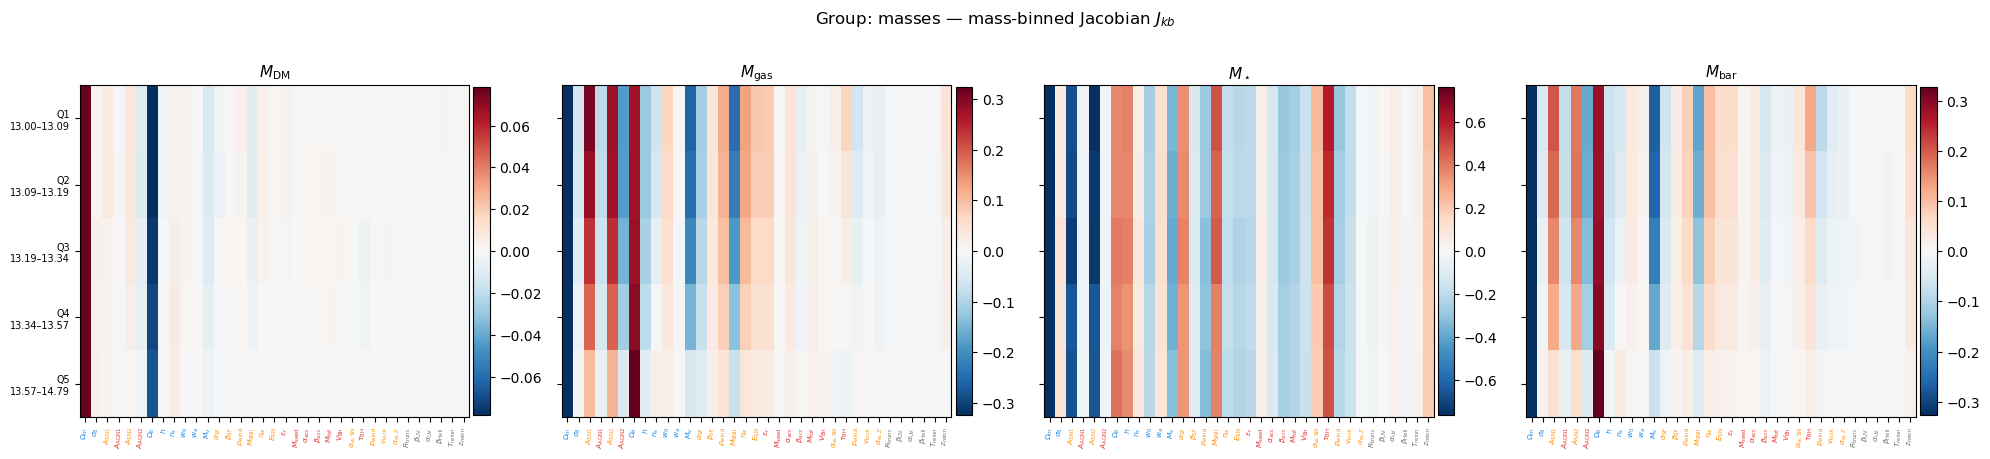

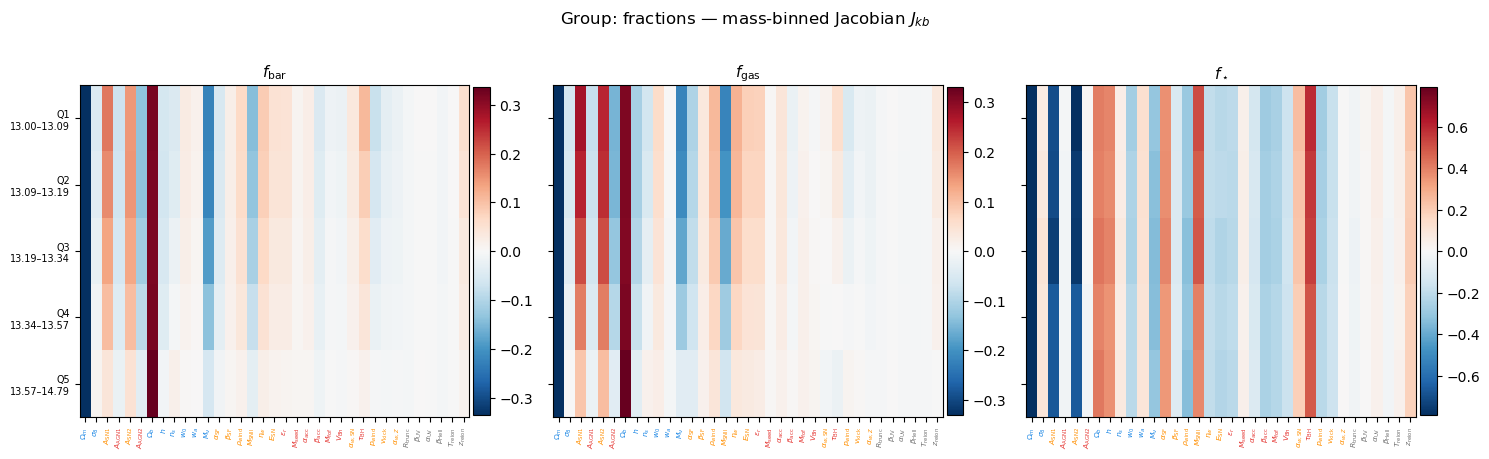

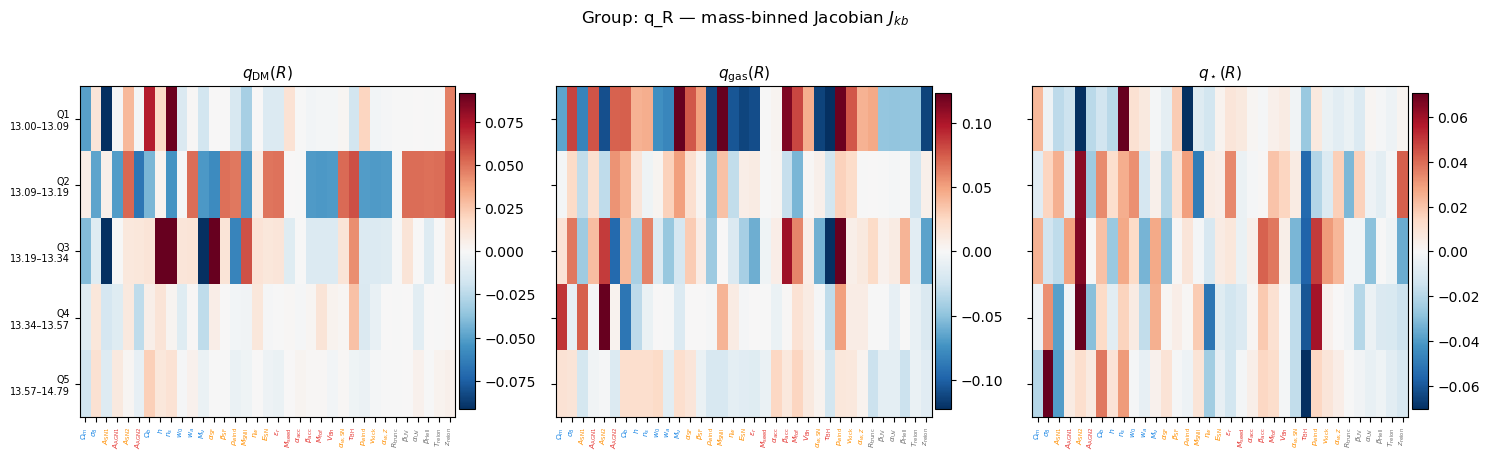

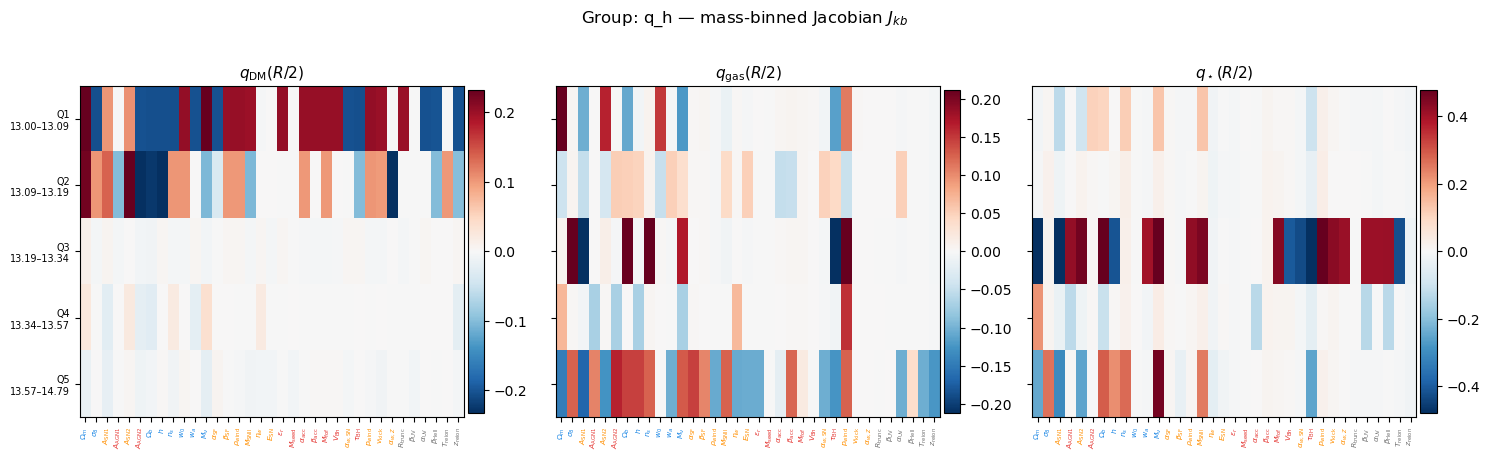

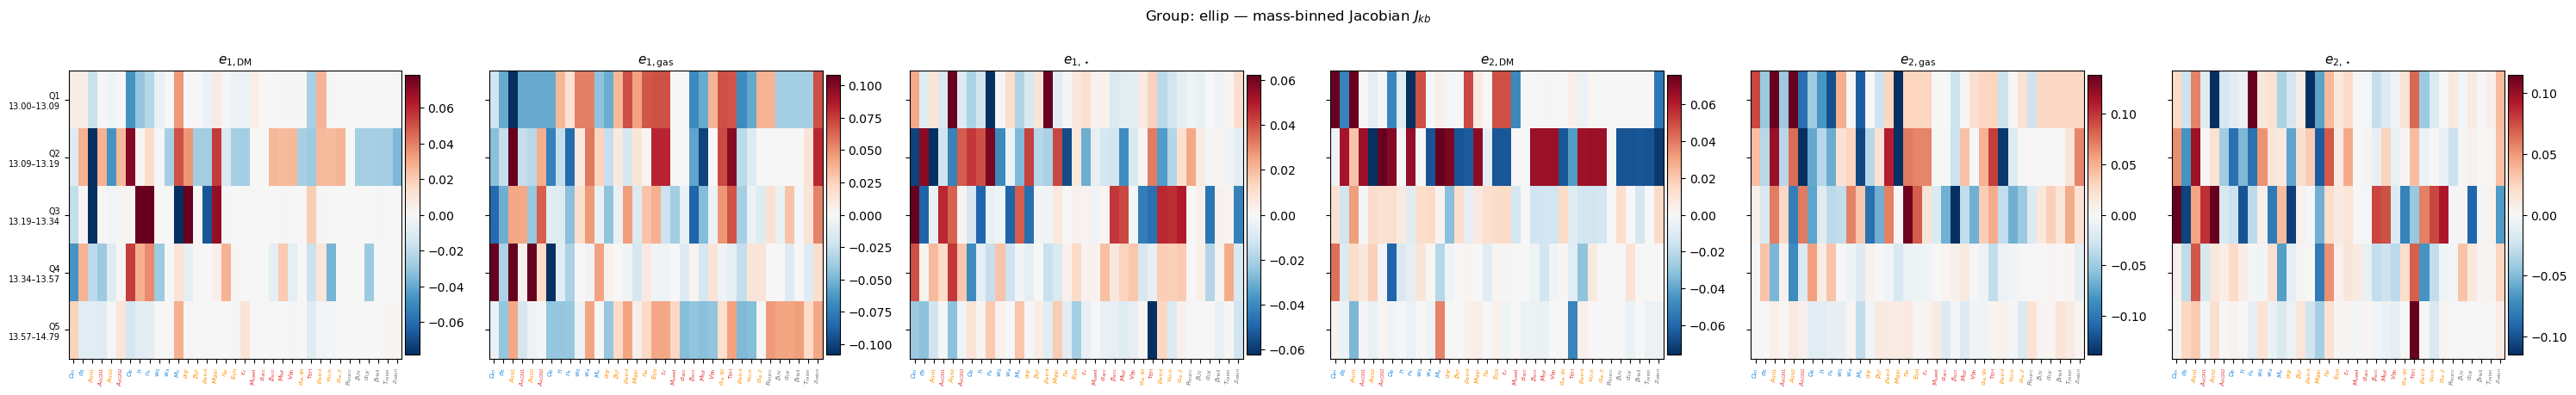

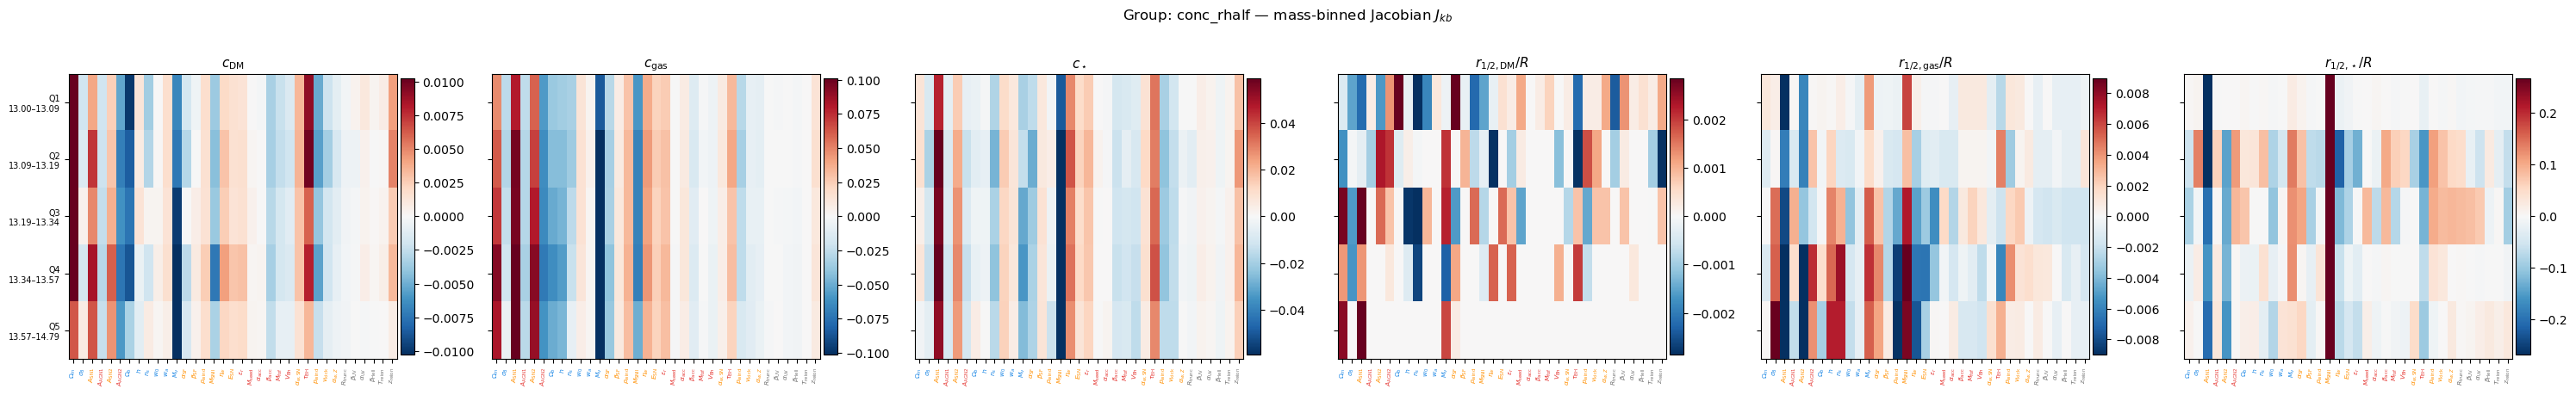

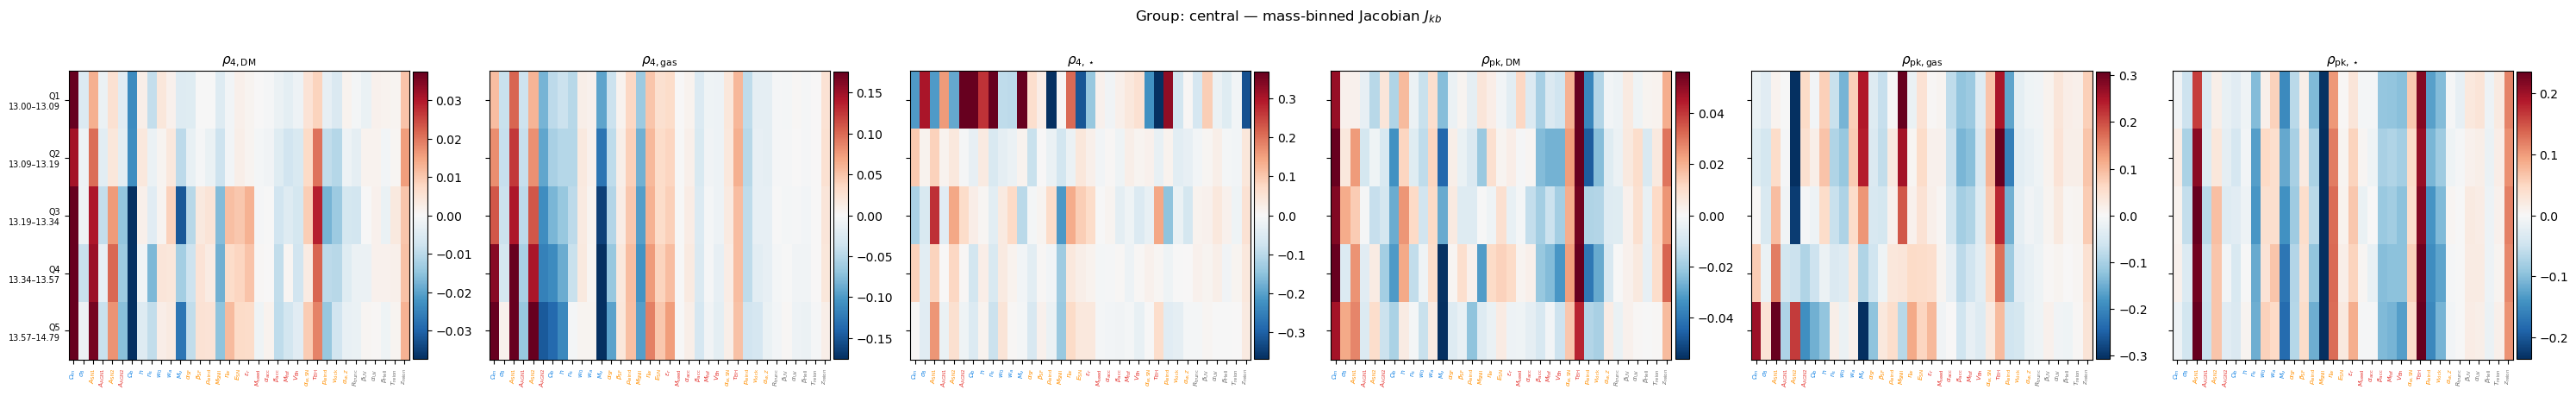

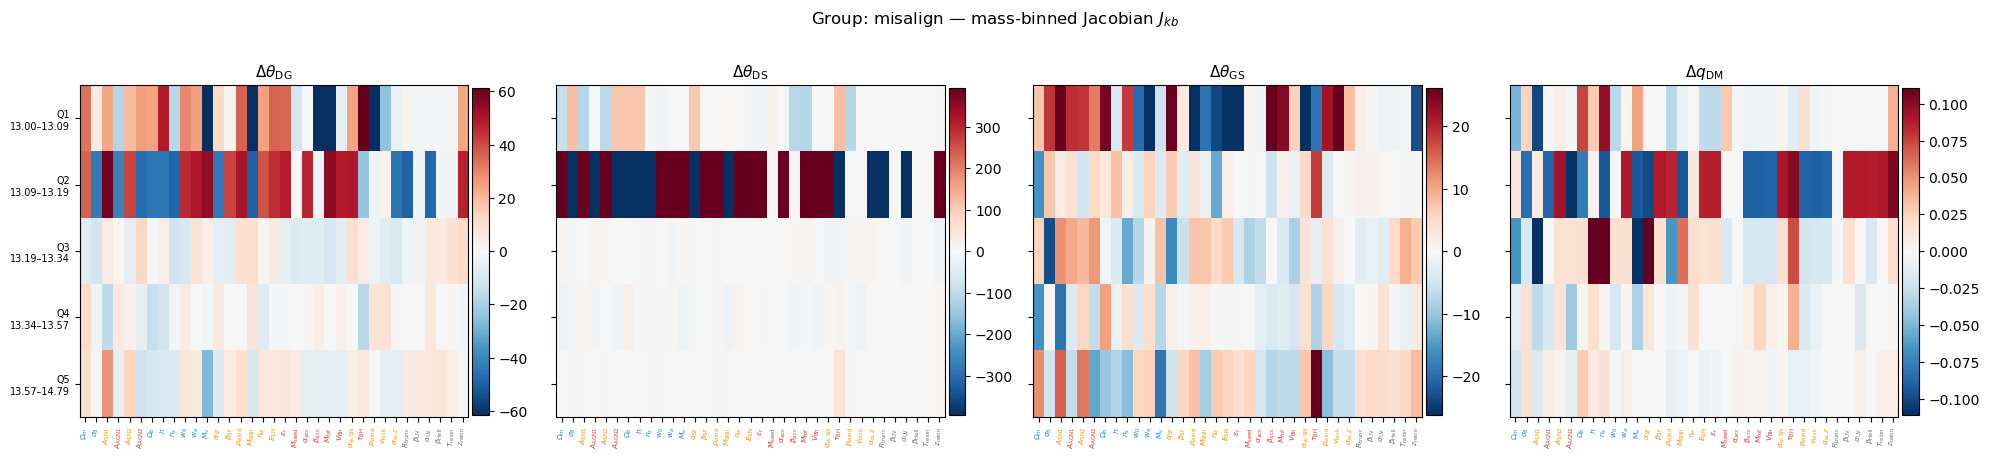

In [7]:
def plot_group_heatmap(group_name, obs_keys):
    n_obs = len(obs_keys)
    fig, axes = plt.subplots(1, n_obs, figsize=(5 * n_obs, 4.5), sharey=True)
    if n_obs == 1:
        axes = [axes]
    for ax, k in zip(axes, obs_keys):
        mat  = mean_per_bin[k]                    # (N_MBINS, 35)
        vmax = max(float(np.nanpercentile(np.abs(mat), 97)), 1e-6)
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        im   = ax.imshow(mat, aspect='auto', cmap='RdBu_r', norm=norm)
        ax.set_xticks(range(N_PARAMS))
        ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                           rotation=90, fontsize=5.5)
        for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
            tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
        ax.set_yticks(range(N_MBINS))
        ax.set_yticklabels([f'Q{b+1}\n{MASS_LABELS[b]}' for b in range(N_MBINS)], fontsize=7)
        ax.set_title(KEY_LATEX[k], fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.01)
    fig.suptitle(f'Group: {group_name} — mass-binned Jacobian $J_{{kb}}$', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

for grp_name, grp_keys in KEY_GROUPS.items():
    plot_group_heatmap(grp_name, grp_keys)


## Observable-Stacked Heatmaps per Mass Bin

One panel per mass quintile. Rows = all 35 per-halo observables; columns = 35 CAMELS parameters.
Shared colour norm across all panels.


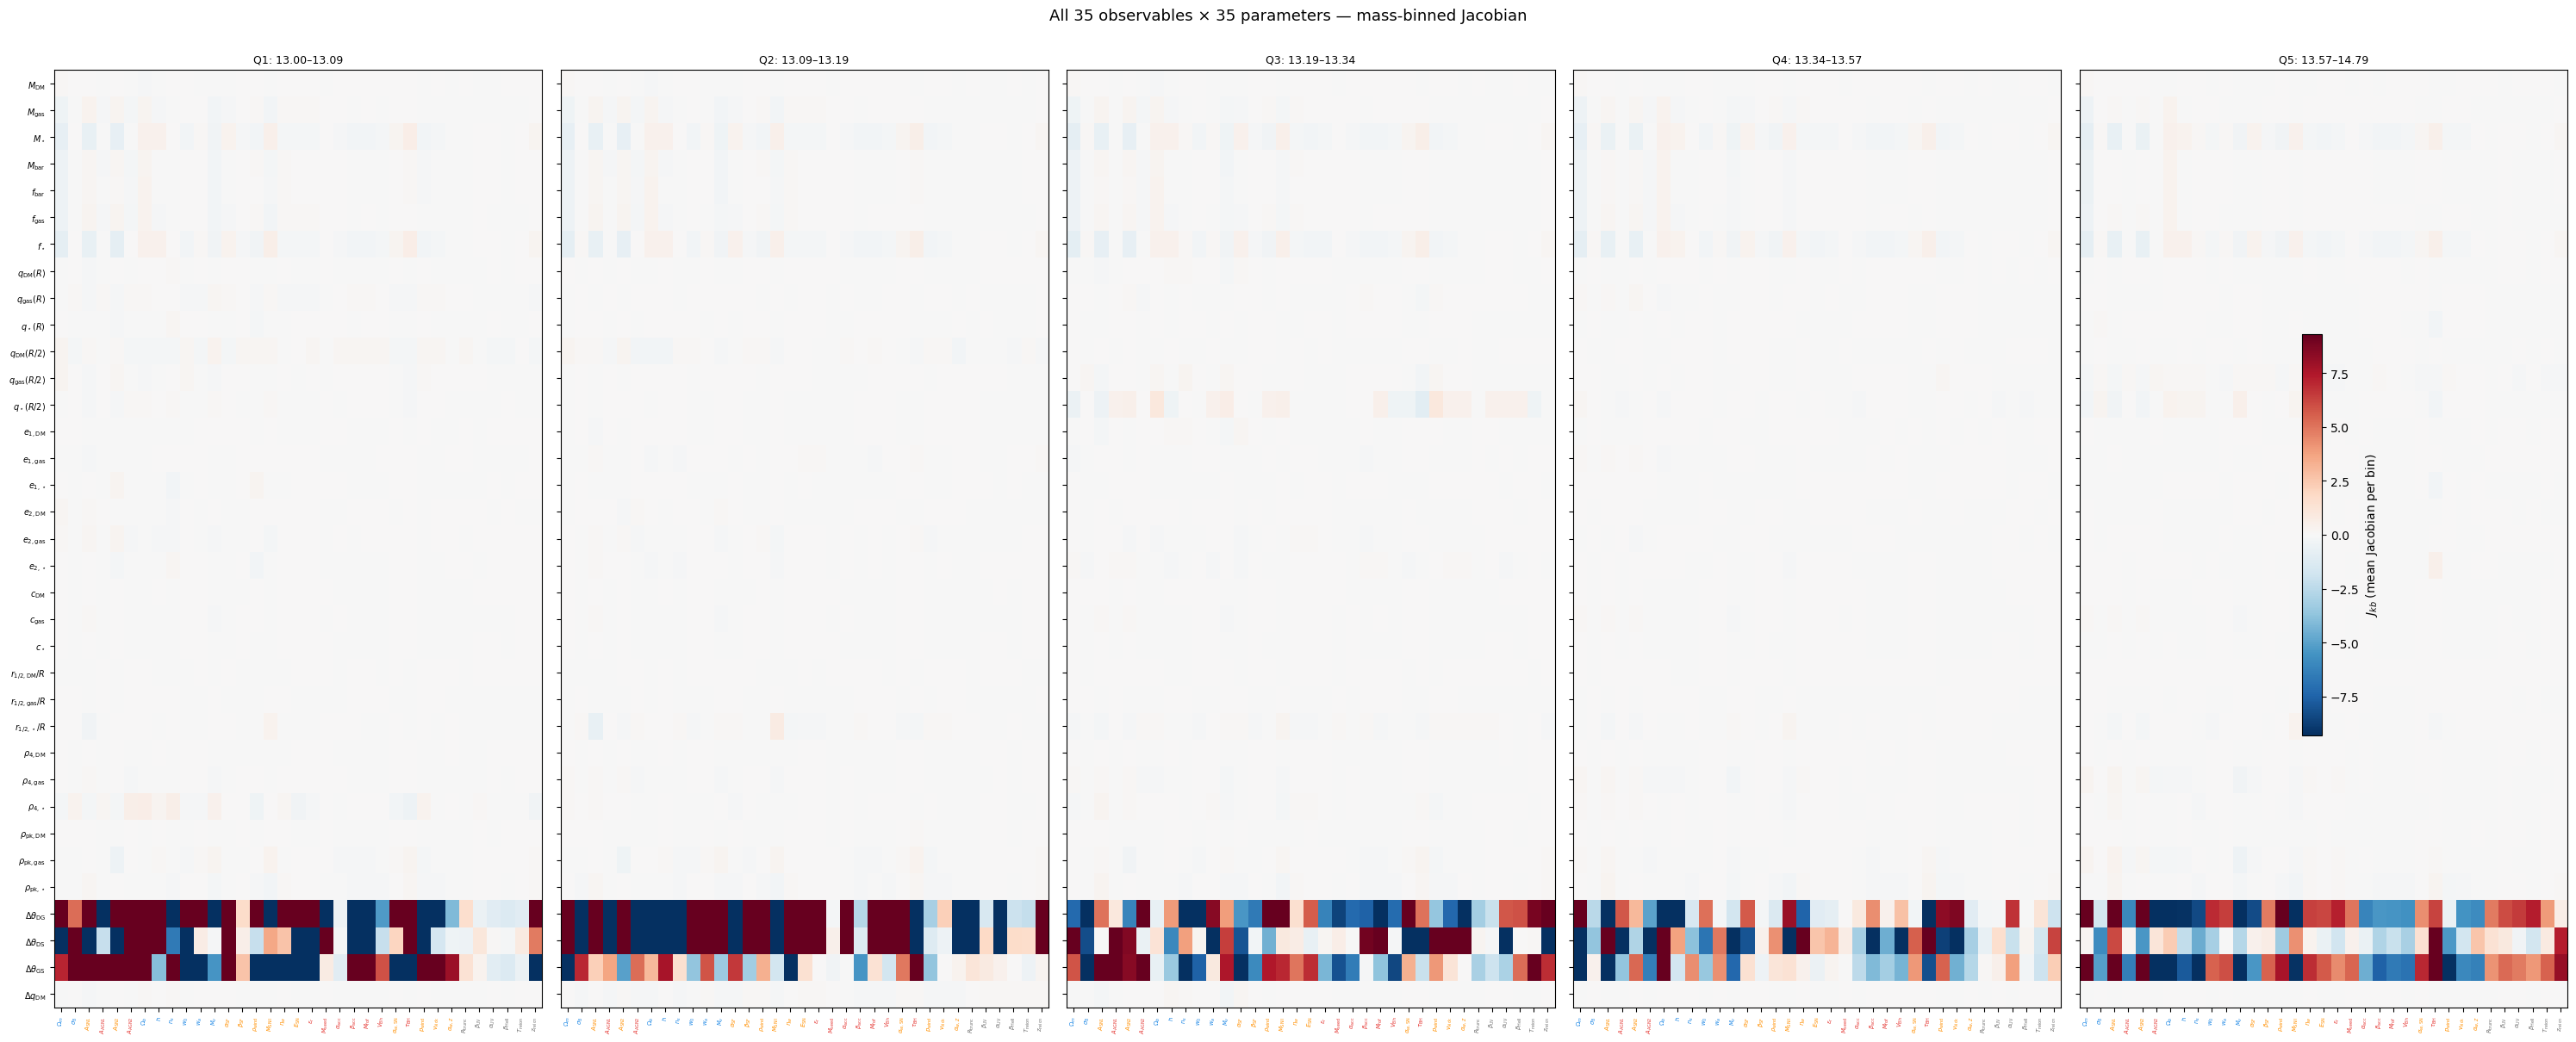

In [8]:
fig, axes = plt.subplots(1, N_MBINS, figsize=(6 * N_MBINS, 12), sharey=True)

# Shared norm across all mass bins
all_vals = np.concatenate([mean_per_bin[k] for k in PER_HALO_KEYS])
vmax_all = max(float(np.nanpercentile(np.abs(all_vals), 97)), 1e-6)
norm_all = TwoSlopeNorm(vmin=-vmax_all, vcenter=0, vmax=vmax_all)

obs_all_labels = [KEY_LATEX[k] for k in PER_HALO_KEYS]

for b, ax in enumerate(axes):
    mat = np.array([mean_per_bin[k][b] for k in PER_HALO_KEYS])  # (35, 35)
    im  = ax.imshow(mat, aspect='auto', cmap='RdBu_r', norm=norm_all)
    ax.set_xticks(range(N_PARAMS))
    ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                       rotation=90, fontsize=5)
    for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
        tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
    if b == 0:
        ax.set_yticks(range(len(PER_HALO_KEYS)))
        ax.set_yticklabels(obs_all_labels, fontsize=7)
    ax.set_title(f'Q{b+1}: {MASS_LABELS[b]}', fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.01, pad=0.01,
             label=r'$J_{kb}$ (mean Jacobian per bin)')
fig.suptitle('All 35 observables × 35 parameters — mass-binned Jacobian', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()


## Top Drivers per Observable vs Halo Mass

Line plot: mean Jacobian $J_{kj}(M)$ for the $N$ parameters with largest mean $|J|$.
Change `OBS_FOCUS` to explore a different observable.


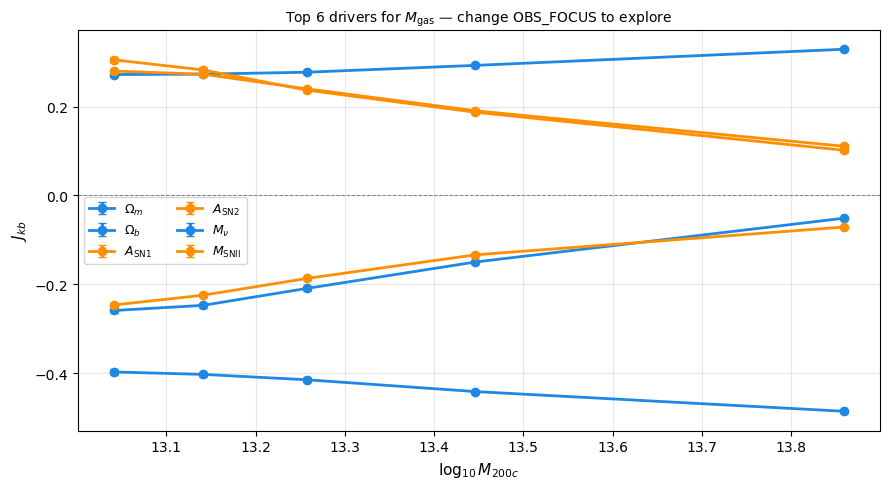

Top 3 parameter drivers per observable (mean |J| over mass bins):
  M_dm            $\Omega_m$ (0.125), $\Omega_b$ (0.074), $M_\nu$ (0.009)
  M_gas           $\Omega_m$ (0.429), $\Omega_b$ (0.289), $A_{\rm SN1}$ (0.223)
  M_star          $\Omega_m$ (0.795), $A_{\rm SN2}$ (0.706), $A_{\rm SN1}$ (0.676)
  M_bar           $\Omega_m$ (0.460), $\Omega_b$ (0.297), $M_\nu$ (0.197)
  f_bar           $\Omega_m$ (0.508), $\Omega_b$ (0.322), $M_\nu$ (0.165)
  f_gas           $\Omega_m$ (0.477), $\Omega_b$ (0.314), $A_{\rm SN1}$ (0.201)
  f_star          $\Omega_m$ (0.846), $A_{\rm SN2}$ (0.730), $A_{\rm SN1}$ (0.699)
  q_dm_R          $n_s$ (0.054), $A_{\rm SN1}$ (0.053), $M_\nu$ (0.052)
  q_gas_R         $A_{\rm SN2}$ (0.076), $\tau_{\rm BH}$ (0.072), $p_{\rm wind}$ (0.068)
  q_star_R        $\tau_{\rm BH}$ (0.086), $A_{\rm SN2}$ (0.068), $n_s$ (0.056)
  q_dm_h          $\Omega_m$ (0.107), $A_{\rm AGN2}$ (0.095), $\Omega_b$ (0.094)
  q_gas_h         $p_{\rm wind}$ (0.131), $A_{\rm SN1}$ (0.108),

In [9]:
OBS_FOCUS = 'M_gas'   # ← change to explore: 'f_bar', 'conc_gas', 'q_dm_R', 'dq_dm', ...
N_DRIVERS = 6

mean_abs_k = np.abs(mean_per_bin[OBS_FOCUS]).mean(axis=0)  # mean over mass bins
top_params = np.argsort(-mean_abs_k)[:N_DRIVERS]

fig, ax = plt.subplots(figsize=(9, 5))
for j in top_params:
    m = mean_per_bin[OBS_FOCUS][:, j]
    s = se_per_bin[OBS_FOCUS][:, j]
    ax.errorbar(mass_centres, m, yerr=s, fmt='o-',
                color=GROUP_COLORS[PARAM_GROUP[j]], lw=2, ms=6, capsize=3,
                label=PRETTY.get(j, str(j)))
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_xlabel(r'$\log_{10} M_{200c}$', fontsize=11)
ax.set_ylabel(r'$J_{kb}$', fontsize=11)
ax.set_title(f'Top {N_DRIVERS} drivers for {KEY_LATEX.get(OBS_FOCUS, OBS_FOCUS)}'
             ' — change OBS_FOCUS to explore', fontsize=10)
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary: top 3 for every observable
print('Top 3 parameter drivers per observable (mean |J| over mass bins):')
for k in PER_HALO_KEYS:
    mabs = np.abs(mean_per_bin[k]).mean(axis=0)
    top3 = np.argsort(-mabs)[:3]
    desc = ', '.join(f'{PRETTY.get(j,j)} ({mabs[j]:.3f})' for j in top3)
    print(f'  {k:14s}  {desc}')


## Population Jacobians — Scaling-Relation Statistics

The FD script fit five scaling relations across all halos at $\pm\epsilon$ parameter
perturbations. The **population Jacobian** $J^{\rm pop}_{kj} = \partial S_k / \partial \tilde\theta_j$
(shape $(35,)$) measures how the population-level slope $\alpha$, intercept $\beta$,
and scatter $\sigma$ of each relation respond to each CAMELS parameter.


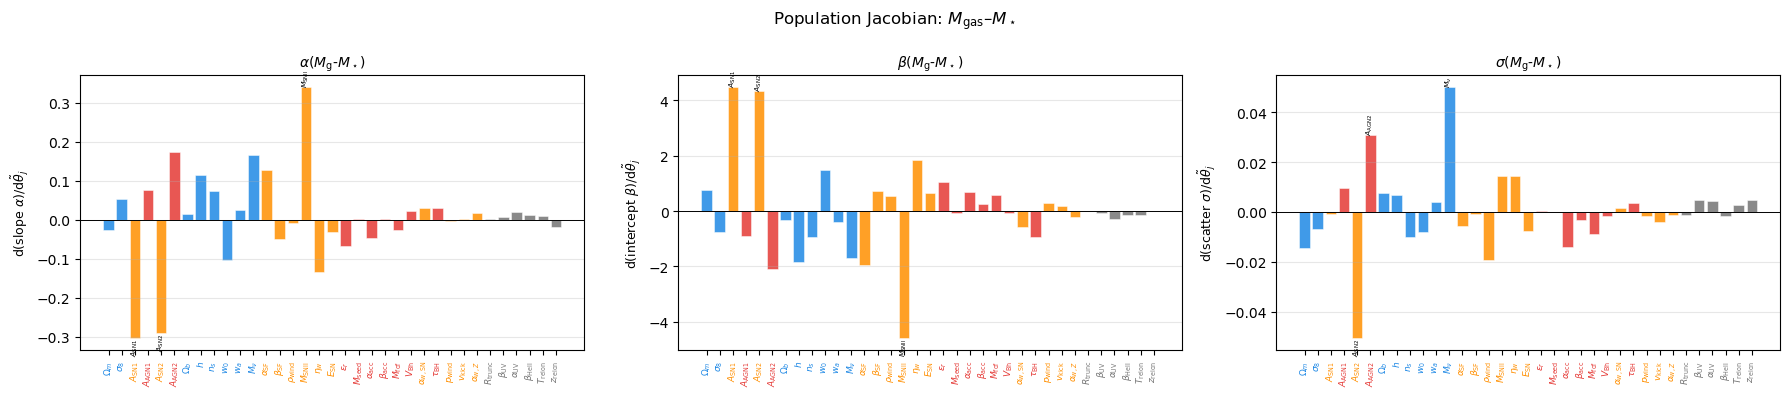

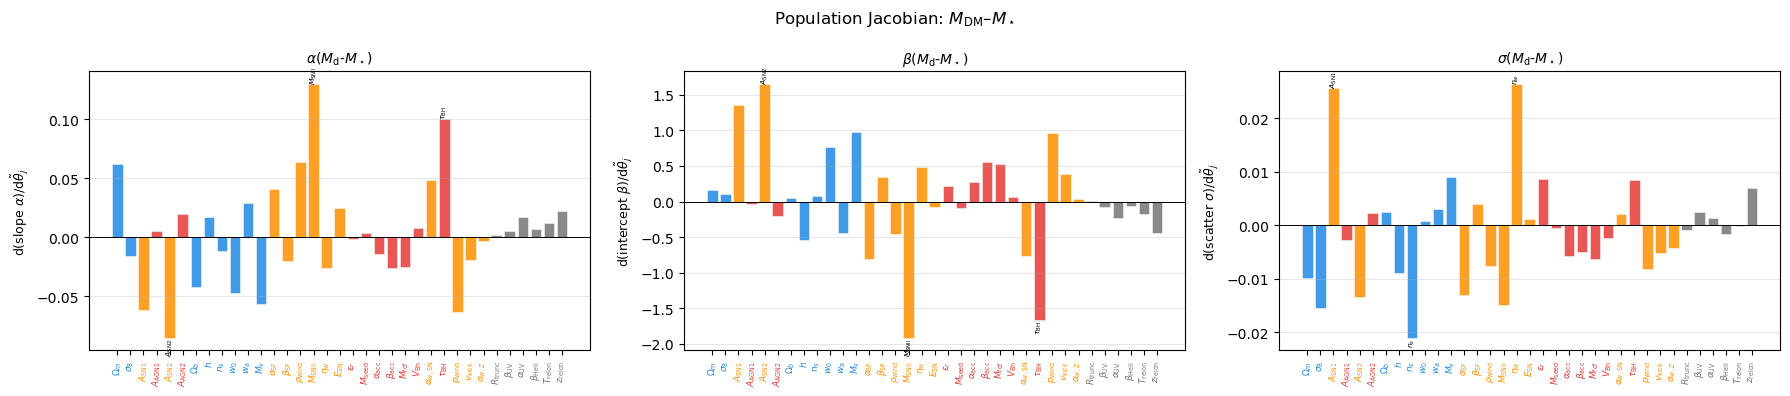

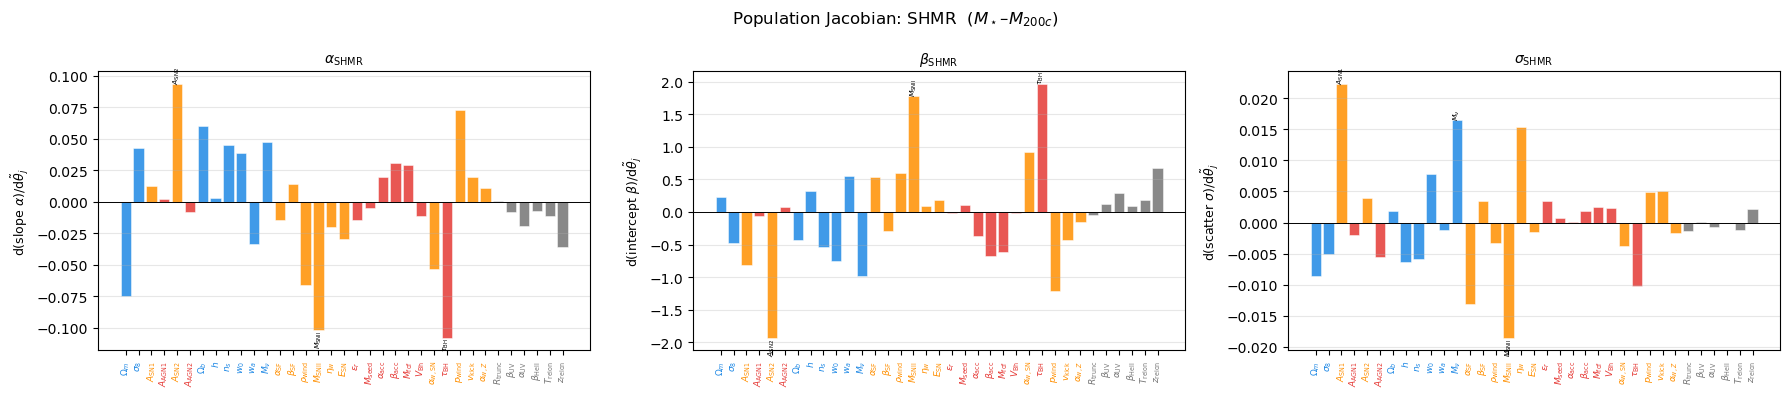

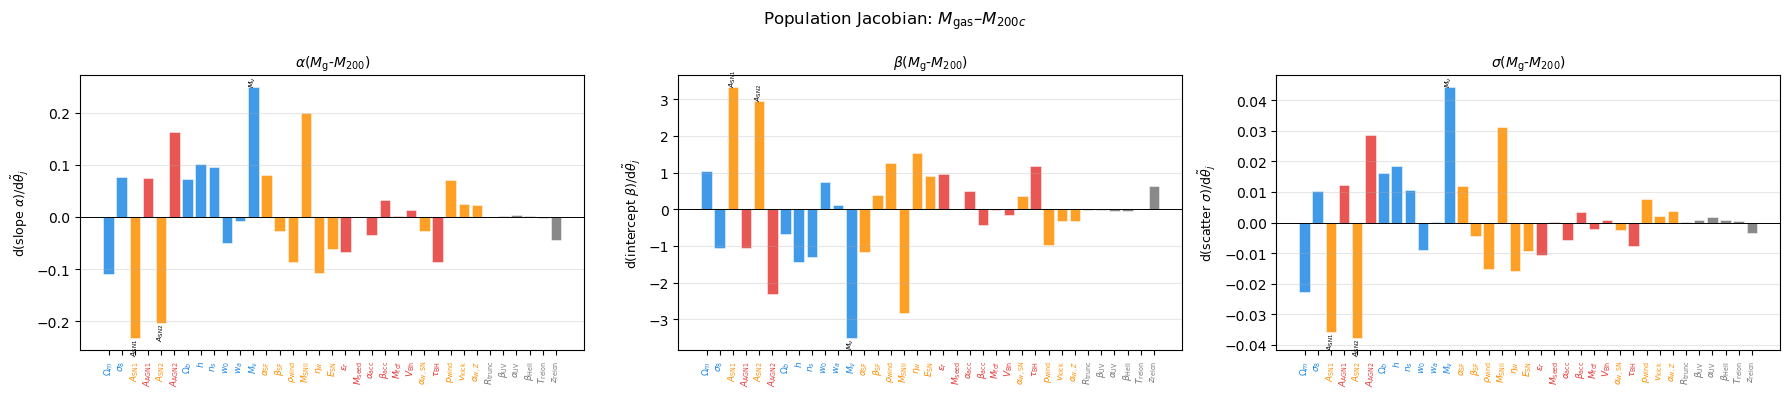

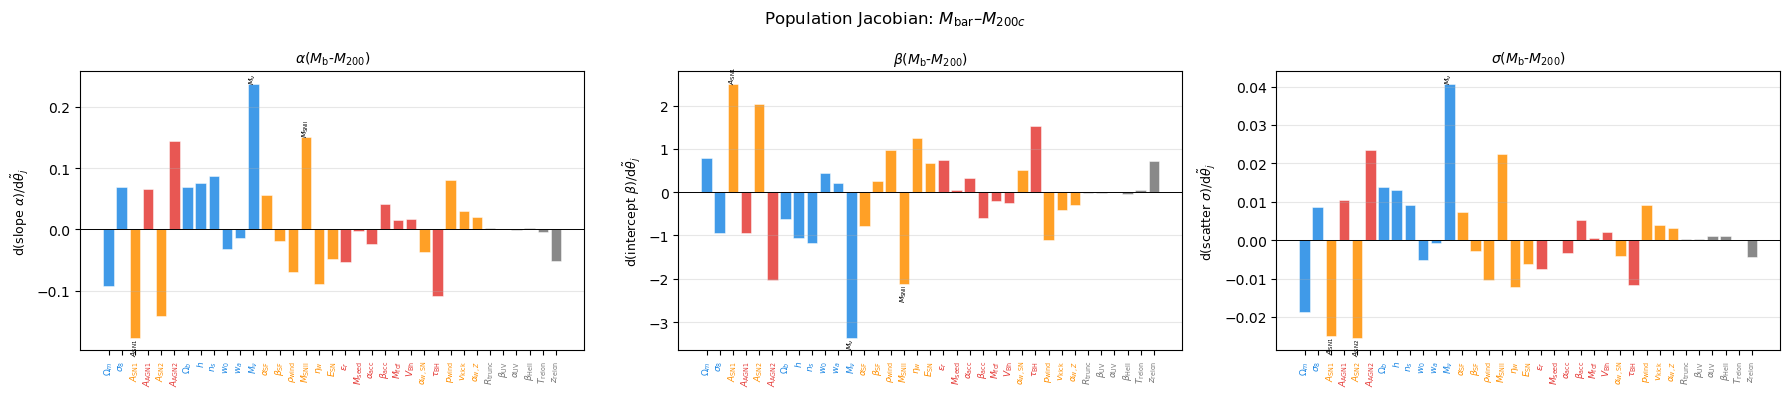

In [10]:
SCALING_RELATIONS = [
    ('MgMs',  r'$M_{\rm gas}$–$M_\star$',         ['alpha_MgMs','beta_MgMs','sigma_MgMs']),
    ('MdMs',  r'$M_{\rm DM}$–$M_\star$',           ['alpha_MdMs','beta_MdMs','sigma_MdMs']),
    ('SHMR',  r'SHMR  ($M_\star$–$M_{200c}$)',      ['alpha_SHMR', 'beta_SHMR', 'sigma_SHMR']),
    ('GasFr', r'$M_{\rm gas}$–$M_{200c}$',          ['alpha_GasFr','beta_GasFr','sigma_GasFr']),
    ('BarFr', r'$M_{\rm bar}$–$M_{200c}$',          ['alpha_BarFr','beta_BarFr','sigma_BarFr']),
]
STAT_LABELS = [r'slope $\alpha$', r'intercept $\beta$', r'scatter $\sigma$']
x = np.arange(N_PARAMS)

for rel_id, rel_latex, keys in SCALING_RELATIONS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
    fig.suptitle(f'Population Jacobian: {rel_latex}', fontsize=12)
    for ax, k, slabel in zip(axes, keys, STAT_LABELS):
        vals   = Jpop[k]
        colors_p = [GROUP_COLORS[PARAM_GROUP[j]] for j in range(N_PARAMS)]
        ax.bar(x, vals, color=colors_p, alpha=0.85, edgecolor='white', lw=0.4)
        ax.axhline(0, color='k', lw=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)],
                           rotation=90, fontsize=6.5)
        for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
            tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
        ax.set_ylabel(f'd({slabel})/d' + r'$\tilde\theta_j$', fontsize=9)
        ax.set_title(POP_LATEX[k], fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        top3 = np.argsort(-np.abs(vals))[:3]
        for jj in top3:
            ax.text(jj, vals[jj], PRETTY.get(jj, str(jj)),
                    ha='center', va='bottom' if vals[jj] >= 0 else 'top',
                    fontsize=5.5, rotation=90)
    plt.tight_layout()
    plt.show()


## Physics Validation

Four checks that the model learned real physics:

1. **Sign audit** — do the signs of median $J_{kj}$ match first-principles expectations?
2. **Chain-rule check** — does $\partial M_{\rm bar}/\partial\tilde\theta_j \approx \partial M_{\rm gas}/\partial\tilde\theta_j + \partial M_\star/\partial\tilde\theta_j$?
3. **Feedback mass-dependence** — do SN/AGN effects weaken at high mass (potential-well suppression)?
4. **Sensitivity budget** — is $M_{\rm DM}$ cosmology-dominated while $M_{\rm gas}$/$M_\star$ are feedback-dominated?


In [11]:
# Expected signs for ∂log10(F)/∂p_norm (= ∂log10(F)/∂p_nat since normalization is monotone).
# For signed observables, sign of ∂F/∂p_norm.
SIGN_PRIORS = [
    # (obs_key,      param_idx,  expected_sign (+1/-1/0),  justification)
    # --- Masses ---
    ('M_dm',    0,  +1, r'$\Omega_m\uparrow$ → deeper potential well → more DM'),
    ('M_dm',    1,  +1, r'$\sigma_8\uparrow$ → higher-peak halo → more DM'),
    ('M_gas',   6,  +1, r'$\Omega_b\uparrow$ → more baryons available'),
    ('M_star',  6,  +1, r'$\Omega_b\uparrow$ → more fuel for SF'),
    ('M_bar',   6,  +1, r'$\Omega_b\uparrow$ → more total baryons'),
    # --- Feedback on masses ---
    ('M_gas',   2,  -1, r'$A_{\rm SN1}\uparrow$ → gas ejection (prior; may be + in CAMELS)'),
    ('M_star',  2,  -1, r'$A_{\rm SN1}\uparrow$ → SN quenches star formation'),
    ('M_gas',   3,  -1, r'$A_{\rm AGN1}\uparrow$ → AGN heats/ejects gas'),
    ('M_star',  3,  -1, r'$A_{\rm AGN1}\uparrow$ → AGN quenches star formation'),
    ('M_gas',   5,  -1, r'$A_{\rm AGN2}\uparrow$ → AGN jet ejects gas'),
    # --- Baryon fractions ---
    ('f_bar',   6,  +1, r'$\Omega_b\uparrow$ → $f_b$ closer to cosmic value'),
    ('f_bar',   2,  -1, r'$A_{\rm SN1}\uparrow$ → ejects baryons → lower $f_b$'),
    ('f_bar',   3,  -1, r'$A_{\rm AGN1}\uparrow$ → ejects baryons → lower $f_b$'),
    ('f_bar',   5,  -1, r'$A_{\rm AGN2}\uparrow$ → ejects gas → lower $f_b$'),
    # --- DM insensitive to baryonic feedback ---
    ('M_dm',    2,   0, r'$A_{\rm SN1}$ should not drive DM at leading order'),
    ('M_dm',    3,   0, r'$A_{\rm AGN1}$ should not drive DM at leading order'),
    # --- Shape: feedback isotropizes ---
    ('q_gas_R', 2,  +1, r'$A_{\rm SN1}\uparrow$ → isotropises gas distribution'),
    ('q_star_R',2,  +1, r'$A_{\rm SN1}\uparrow$ → isotropises stellar distribution'),
    ('q_dm_R',  2,   0, r'$A_{\rm SN1}$ has sub-dominant effect on DM shape'),
    # --- Concentration: feedback reduces central density ---
    ('conc_gas', 2, -1, r'$A_{\rm SN1}\uparrow$ → blows out central gas'),
    ('conc_star',2, -1, r'$A_{\rm SN1}\uparrow$ → disrupts central stellar concentration'),
    # --- Baryonic spherization ---
    ('dq_dm',   2,  +1, r'$A_{\rm SN1}\uparrow$ → baryonic back-reaction makes DM rounder'),
]

J_median = {k: np.nanmedian(J_view[k], axis=0) for k in PER_HALO_KEYS}
rows = []
n_pass = n_fail = n_small = 0
for obs, pidx, exp, justif in SIGN_PRIORS:
    val   = float(J_median[obs][pidx])
    pname = PRETTY.get(pidx, str(pidx))
    if exp == 0:
        scale  = max(np.nanmax(np.abs(J_median[obs])), 1e-30)
        result = '✓ SMALL' if np.abs(val) < 0.05 * scale else '✗ LARGE'
        if '✓' in result: n_small += 1
        else:              n_fail  += 1
    else:
        result = '✓ PASS' if np.sign(val) == exp else '✗ FAIL'
        if '✓' in result: n_pass += 1
        else:              n_fail += 1
    rows.append((obs, pname, exp, f'{val:+.4f}', justif, result))

print(f'{"Observable":<16}  {"Param":<24}  {"Exp":>4}  {"Model":>8}  Result')
print('-' * 95)
for obs, pname, exp, val, just, result in rows:
    exp_str = '+' if exp == +1 else ('-' if exp == -1 else '~0')
    print(f'{obs:<16}  {pname:<24}  {exp_str:>4}  {val:>8}  {result}')
print(f'\nSummary: {n_pass} pass, {n_small} near-zero, {n_fail} fail '
      f'(pass rate: {(n_pass+n_small)/(n_pass+n_small+n_fail):.1%})')


Observable        Param                      Exp     Model  Result
-----------------------------------------------------------------------------------------------
M_dm              $\Omega_m$                   +   +0.1251  ✓ PASS
M_dm              $\sigma_8$                   +   +0.0021  ✓ PASS
M_gas             $\Omega_b$                   +   +0.2938  ✓ PASS
M_star            $\Omega_b$                   +   +0.3668  ✓ PASS
M_bar             $\Omega_b$                   +   +0.2998  ✓ PASS
M_gas             $A_{\rm SN1}$                -   +0.2166  ✗ FAIL
M_star            $A_{\rm SN1}$                -   -0.6503  ✓ PASS
M_gas             $A_{\rm AGN1}$               -   -0.0629  ✓ PASS
M_star            $A_{\rm AGN1}$               -   -0.0304  ✓ PASS
M_gas             $A_{\rm AGN2}$               -   -0.1330  ✓ PASS
f_bar             $\Omega_b$                   +   +0.3246  ✓ PASS
f_bar             $A_{\rm SN1}$                -   +0.1164  ✗ FAIL
f_bar             $A_{\rm AGN1}$ 

Chain-rule check: ∂M_bar/∂p̃ ≈ ∂M_gas/∂p̃ + ∂M_star/∂p̃
  Median R² = 1.000
  Frac R² > 0.9: 100.0%
  Params with R² < 0.7:


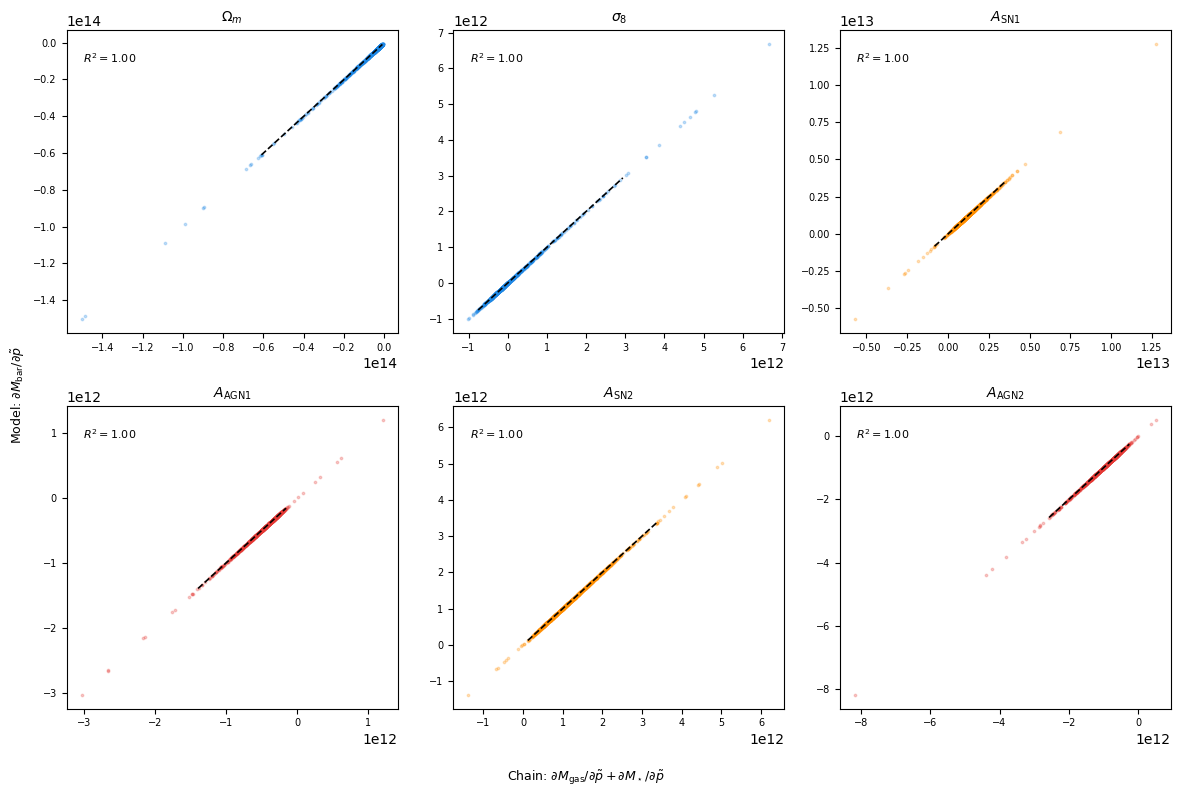

In [12]:
# Check 2: ∂M_bar/∂p ≈ ∂M_gas/∂p + ∂M_star/∂p  (use raw ∂F/∂p_norm view)
dM_bar_model = J_obs_dnorm_all['M_bar']       # (N_USE, 35) direct model output
dM_gas       = J_obs_dnorm_all['M_gas']
dM_star      = J_obs_dnorm_all['M_star']
dM_bar_chain = dM_gas + dM_star               # chain-rule prediction

resid  = dM_bar_chain - dM_bar_model
SS_res = np.nansum(resid**2, axis=0)
SS_tot = np.nansum((dM_bar_model - np.nanmean(dM_bar_model, axis=0))**2, axis=0)
r2     = 1.0 - SS_res / np.where(SS_tot > 0, SS_tot, np.nan)

print('Chain-rule check: ∂M_bar/∂p̃ ≈ ∂M_gas/∂p̃ + ∂M_star/∂p̃')
print(f'  Median R² = {np.nanmedian(r2):.3f}')
print(f'  Frac R² > 0.9: {np.nanmean(r2 > 0.9):.1%}')
print(f'  Params with R² < 0.7:')
for j in np.where(r2 < 0.7)[0]:
    print(f'    {PRETTY.get(j, j):22s}  R²={r2[j]:.3f}')

KEY_PARAMS_CR = [0, 1, 2, 3, 4, 5]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for ax_i, j in enumerate(KEY_PARAMS_CR):
    ax = axes[ax_i]
    x  = dM_bar_chain[:, j]
    y  = dM_bar_model[:, j]
    fin = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[fin], y[fin], s=3, alpha=0.25, color=GROUP_COLORS[PARAM_GROUP[j]])
    lo = min(np.nanpercentile(x[fin], 1), np.nanpercentile(y[fin], 1))
    hi = max(np.nanpercentile(x[fin], 99), np.nanpercentile(y[fin], 99))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2)
    ax.set_title(PRETTY.get(j, str(j)), fontsize=10)
    ax.text(0.05, 0.93, f'$R^2={r2[j]:.2f}$', transform=ax.transAxes, fontsize=8, va='top')
    ax.tick_params(labelsize=7)
fig.supxlabel(r'Chain: $\partial M_{\rm gas}/\partial\tilde p + \partial M_\star/\partial\tilde p$',
              fontsize=9, y=0.01)
fig.supylabel(r'Model: $\partial M_{\rm bar}/\partial\tilde p$', fontsize=9)
plt.tight_layout()
plt.savefig('./paper_figures/Mbar_chain_rule_check.pdf', bbox_inches='tight')
plt.show()


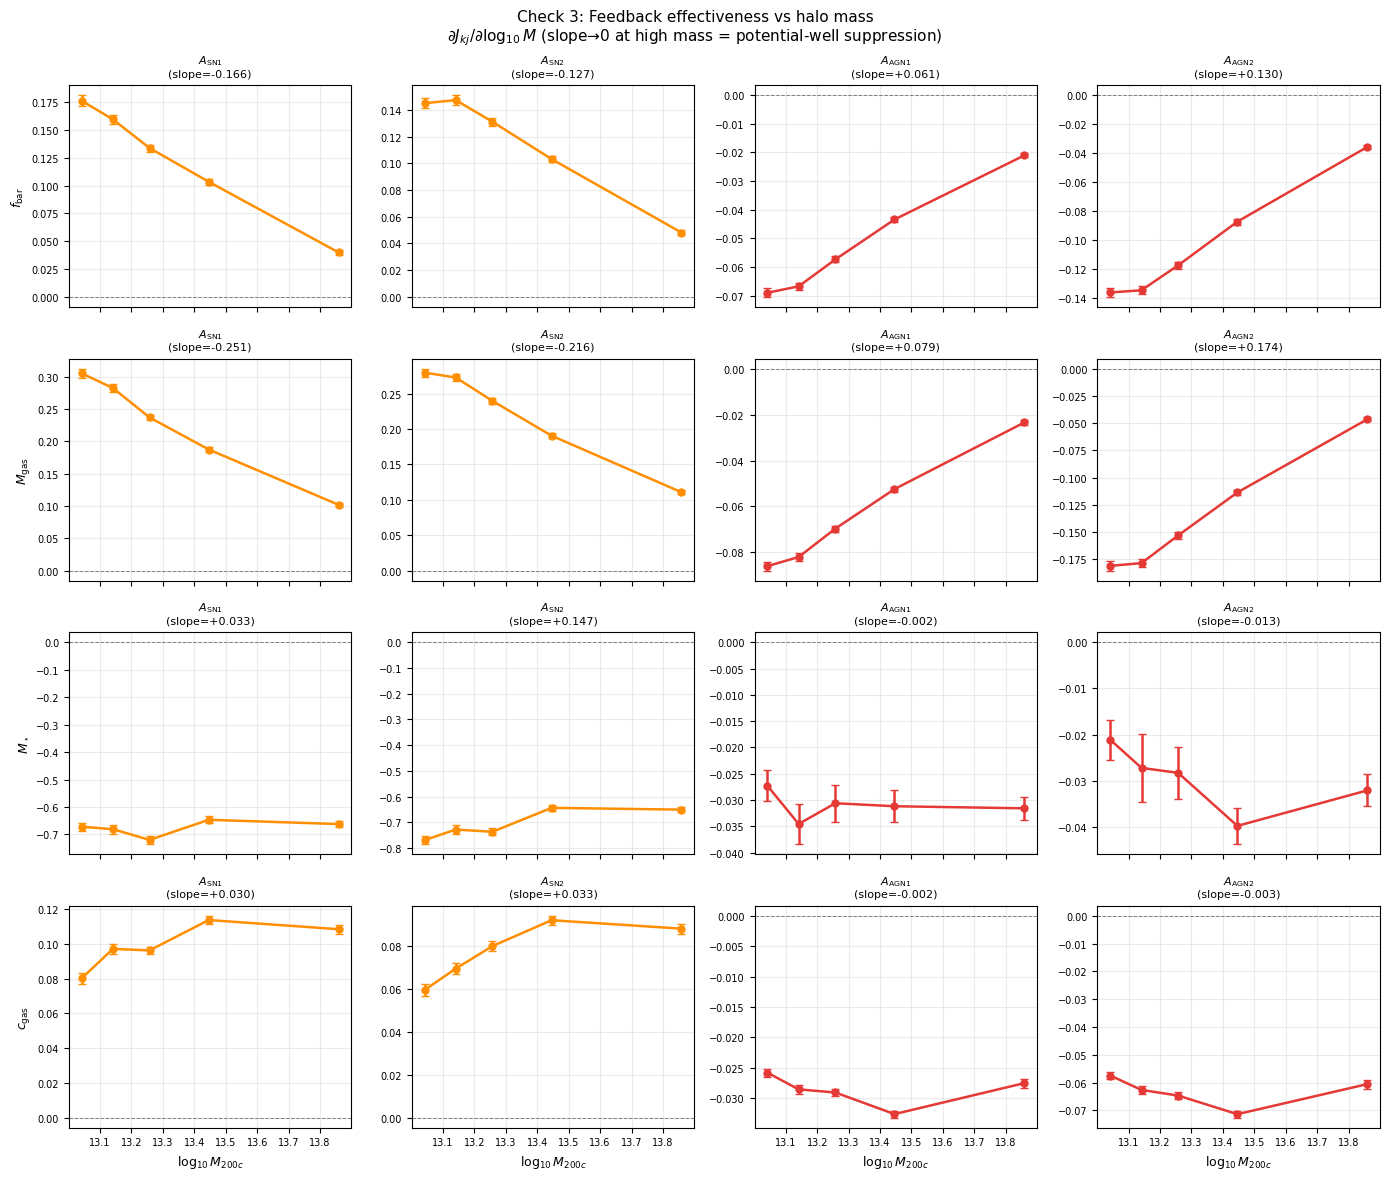

In [13]:
# Check 3: Feedback effectiveness vs halo mass
FEEDBACK_PARAMS = {
    r'$A_{\rm SN1}$':  (2, 'SN'),
    r'$A_{\rm SN2}$':  (4, 'SN'),
    r'$A_{\rm AGN1}$': (3, 'AGN'),
    r'$A_{\rm AGN2}$': (5, 'AGN'),
}
OBS_FB = ['f_bar', 'M_gas', 'M_star', 'conc_gas']

fig, axes = plt.subplots(len(OBS_FB), len(FEEDBACK_PARAMS),
                         figsize=(14, 12), sharex=True)
for row, obs in enumerate(OBS_FB):
    for col, (plabel, (pidx, ptype)) in enumerate(FEEDBACK_PARAMS.items()):
        ax = axes[row, col]
        m  = mean_per_bin[obs][:, pidx]
        s  = se_per_bin[obs][:, pidx]
        col_c = GROUP_COLORS['SN'] if ptype == 'SN' else GROUP_COLORS['AGN']
        ax.errorbar(mass_centres, m, yerr=s, fmt='o-', color=col_c, lw=1.8, ms=5, capsize=3)
        ax.axhline(0, color='gray', lw=0.7, ls='--')
        fin = np.isfinite(m)
        if fin.sum() >= 3:
            slope_fb = np.polyfit(mass_centres[fin], m[fin], 1)[0]
            ax.set_title(f'{plabel}\n(slope={slope_fb:+.3f})', fontsize=8)
        else:
            ax.set_title(plabel, fontsize=8)
        if col == 0:
            ax.set_ylabel(KEY_LATEX[obs], fontsize=9)
        if row == len(OBS_FB) - 1:
            ax.set_xlabel(r'$\log_{10}M_{200c}$', fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=7)

fig.suptitle('Check 3: Feedback effectiveness vs halo mass\n'
             r'$\partial J_{kj}/\partial\log_{10}M$ (slope→0 at high mass = potential-well suppression)',
             fontsize=11)
plt.tight_layout()
plt.show()


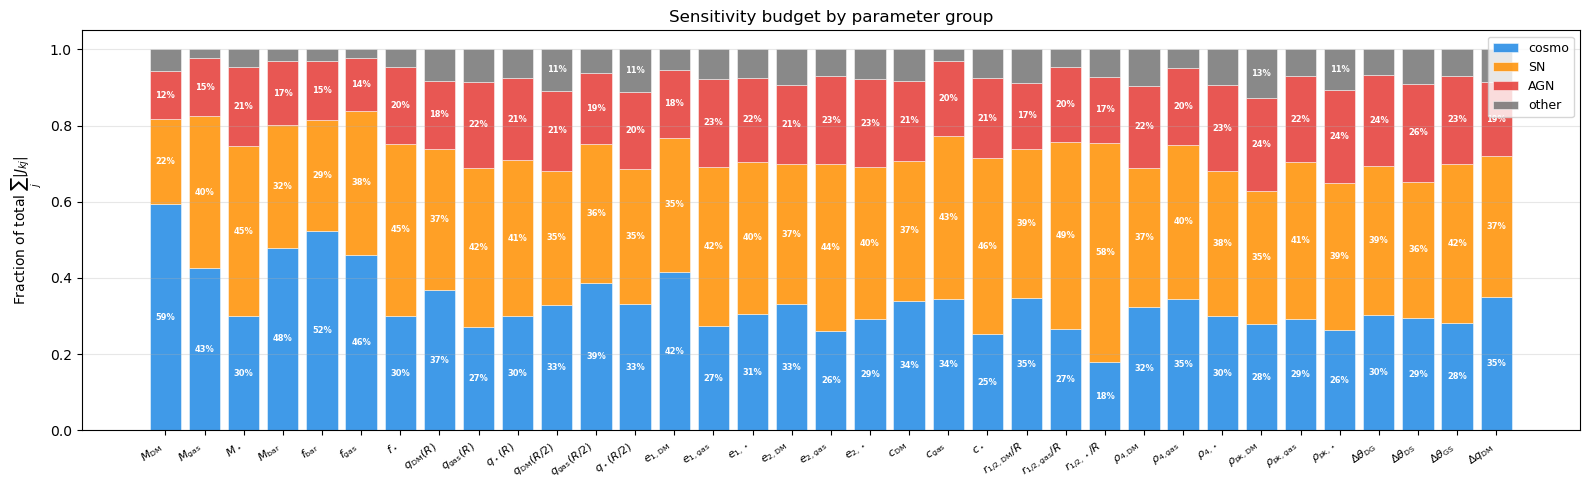


Sensitivity budget:
Observable           cosmo        SN       AGN     other
-------------------------------------------------------
M_dm                59.5%    22.3%    12.4%     5.8%
M_gas               42.6%    39.9%    15.1%     2.4%
M_star              29.9%    44.7%    20.6%     4.8%
M_bar               48.0%    32.1%    16.8%     3.2%
f_bar               52.4%    29.1%    15.4%     3.1%
f_gas               46.0%    37.9%    13.9%     2.2%
f_star              30.1%    45.1%    20.2%     4.6%
q_dm_R              36.9%    36.9%    17.9%     8.2%
q_gas_R             27.2%    41.8%    22.5%     8.5%
q_star_R            29.9%    41.0%    21.4%     7.6%
q_dm_h              33.0%    35.0%    21.2%    10.8%
q_gas_h             38.8%    36.4%    18.7%     6.1%
q_star_h            33.1%    35.4%    20.2%    11.2%
e1_dm               41.6%    35.2%    17.8%     5.4%
e1_gas              27.4%    41.9%    23.0%     7.8%
e1_star             30.5%    40.0%    21.9%     7.5%
e2_dm             

In [14]:
# Check 4: Sensitivity budget by parameter group
group_order  = ['cosmo','SN','AGN','other']
group_to_idx = {g: [j for j in range(N_PARAMS) if PARAM_GROUP[j] == g]
                for g in group_order}

frac_dict = {}
for k in PER_HALO_KEYS:
    arr_abs = np.abs(J_view[k])
    total   = float(np.nansum(arr_abs))
    if total == 0:
        continue
    frac_dict[k] = {g: float(np.nansum(arr_abs[:, group_to_idx[g]])) / total
                    for g in group_order}

fig, ax = plt.subplots(figsize=(16, 5))
obs_labels_sb = [KEY_LATEX[k] for k in PER_HALO_KEYS]
x = np.arange(len(PER_HALO_KEYS))
bottom = np.zeros(len(PER_HALO_KEYS))
for g in group_order:
    vals = np.array([frac_dict.get(k, {}).get(g, 0) for k in PER_HALO_KEYS])
    ax.bar(x, vals, bottom=bottom, color=GROUP_COLORS[g], label=g,
           alpha=0.85, edgecolor='white', lw=0.4)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 0.10:
            ax.text(xi, b + v / 2, f'{v:.0%}', ha='center', va='center',
                    fontsize=6, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(obs_labels_sb, rotation=35, ha='right', fontsize=8)
ax.set_ylabel(r'Fraction of total $\sum_j|J_{kj}|$', fontsize=10)
ax.set_title('Sensitivity budget by parameter group', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nSensitivity budget:')
print(f'{"Observable":<16}' + ''.join(f'  {g:>8}' for g in group_order))
print('-' * 55)
for k in PER_HALO_KEYS:
    row = f'{k:<16}'
    for g in group_order:
        row += f'  {frac_dict.get(k,{}).get(g,0):>7.1%}'
    print(row)


## Full Jacobian Matrix Analysis — SVD

The SVD $\mathbf{J} = U \Sigma V^T$ decomposes the halo-mean Jacobian into orthogonal modes:

- **Right singular vectors** $V$ (rows): parameter-space combinations that drive the most observable variation.
- **Left singular vectors** $U$ (columns): observable combinations that carry the most parameter information.
- **Singular values** $\sigma_i$: mode importance.

Leading modes should correspond to recognizable physical axes (cosmology, SN feedback, AGN).


Jacobian matrix for SVD: (32, 35)  (32 observables × 35 params)


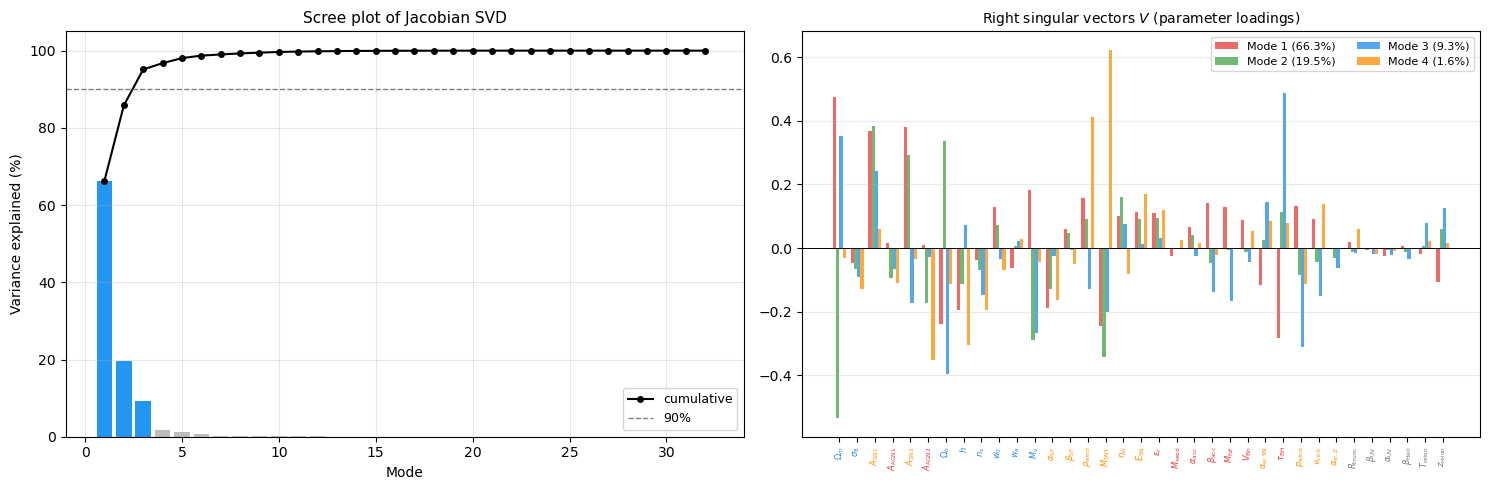


Dominant parameters per SVD mode:
  Mode 1 [66.3%]: $\Omega_m$ (+0.475), $A_{\rm SN2}$ (+0.380), $A_{\rm SN1}$ (+0.369), $\tau_{\rm BH}$ (-0.284), $M_{\rm SNII}$ (-0.246)
  Mode 2 [19.5%]: $\Omega_m$ (-0.535), $A_{\rm SN1}$ (+0.385), $M_{\rm SNII}$ (-0.341), $\Omega_b$ (+0.335), $A_{\rm SN2}$ (+0.293)
  Mode 3 [9.3%]: $\tau_{\rm BH}$ (+0.486), $\Omega_b$ (-0.397), $\Omega_m$ (+0.351), $p_{\rm wind}$ (-0.310), $M_\nu$ (-0.268)
  Mode 4 [1.6%]: $M_{\rm SNII}$ (+0.623), $\rho_{\rm wind}$ (+0.411), $A_{\rm AGN2}$ (-0.352), $h$ (-0.305), $n_s$ (-0.195)


In [15]:
EXCLUDE_SVD  = {'dtheta_dg', 'dtheta_ds', 'dtheta_gs'}
OBS_SVD_KEYS = [k for k in PER_HALO_KEYS
                if np.isfinite(J_view[k]).mean() > 0.5 and k not in EXCLUDE_SVD]
J_mean = np.array([np.nanmean(J_view[k], axis=0) for k in OBS_SVD_KEYS])  # (N_obs, 35)
print(f"Jacobian matrix for SVD: {J_mean.shape}  ({len(OBS_SVD_KEYS)} observables × {N_PARAMS} params)")

U, sv, Vt = np.linalg.svd(J_mean, full_matrices=False)
n_modes     = len(sv)
var_expl    = sv**2 / (sv**2).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
ax = axes[0]
ax.bar(range(1, n_modes+1), var_expl*100,
       color=['#2196F3' if i < 3 else '#BDBDBD' for i in range(n_modes)])
ax.plot(range(1, n_modes+1), np.cumsum(var_expl)*100, 'k-o', ms=4, lw=1.5, label='cumulative')
ax.axhline(90, color='gray', ls='--', lw=1, label='90%')
ax.set_xlabel('Mode', fontsize=10); ax.set_ylabel('Variance explained (%)', fontsize=10)
ax.set_title('Scree plot of Jacobian SVD', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Top-4 right singular vectors (parameter loadings)
N_SHOW  = min(4, n_modes)
ax      = axes[1]
cmap_m  = ['#E53935','#43A047','#1E88E5','#FB8C00']
width   = 0.18
offsets = np.linspace(-(N_SHOW-1)*width/2, (N_SHOW-1)*width/2, N_SHOW)
for mi in range(N_SHOW):
    v = Vt[mi]
    ax.bar(np.arange(N_PARAMS) + offsets[mi], v, width=width, alpha=0.75,
           color=cmap_m[mi], label=f'Mode {mi+1} ({var_expl[mi]:.1%})')
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(range(N_PARAMS))
ax.set_xticklabels([PRETTY.get(j, str(j)) for j in range(N_PARAMS)], rotation=90, fontsize=6)
for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
ax.set_title('Right singular vectors $V$ (parameter loadings)', fontsize=10)
ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('\nDominant parameters per SVD mode:')
for mi in range(N_SHOW):
    top5 = np.argsort(-np.abs(Vt[mi]))[:5]
    desc = ', '.join(f'{PRETTY.get(j,j)} ({Vt[mi,j]:+.3f})' for j in top5)
    print(f'  Mode {mi+1} [{var_expl[mi]:.1%}]: {desc}')


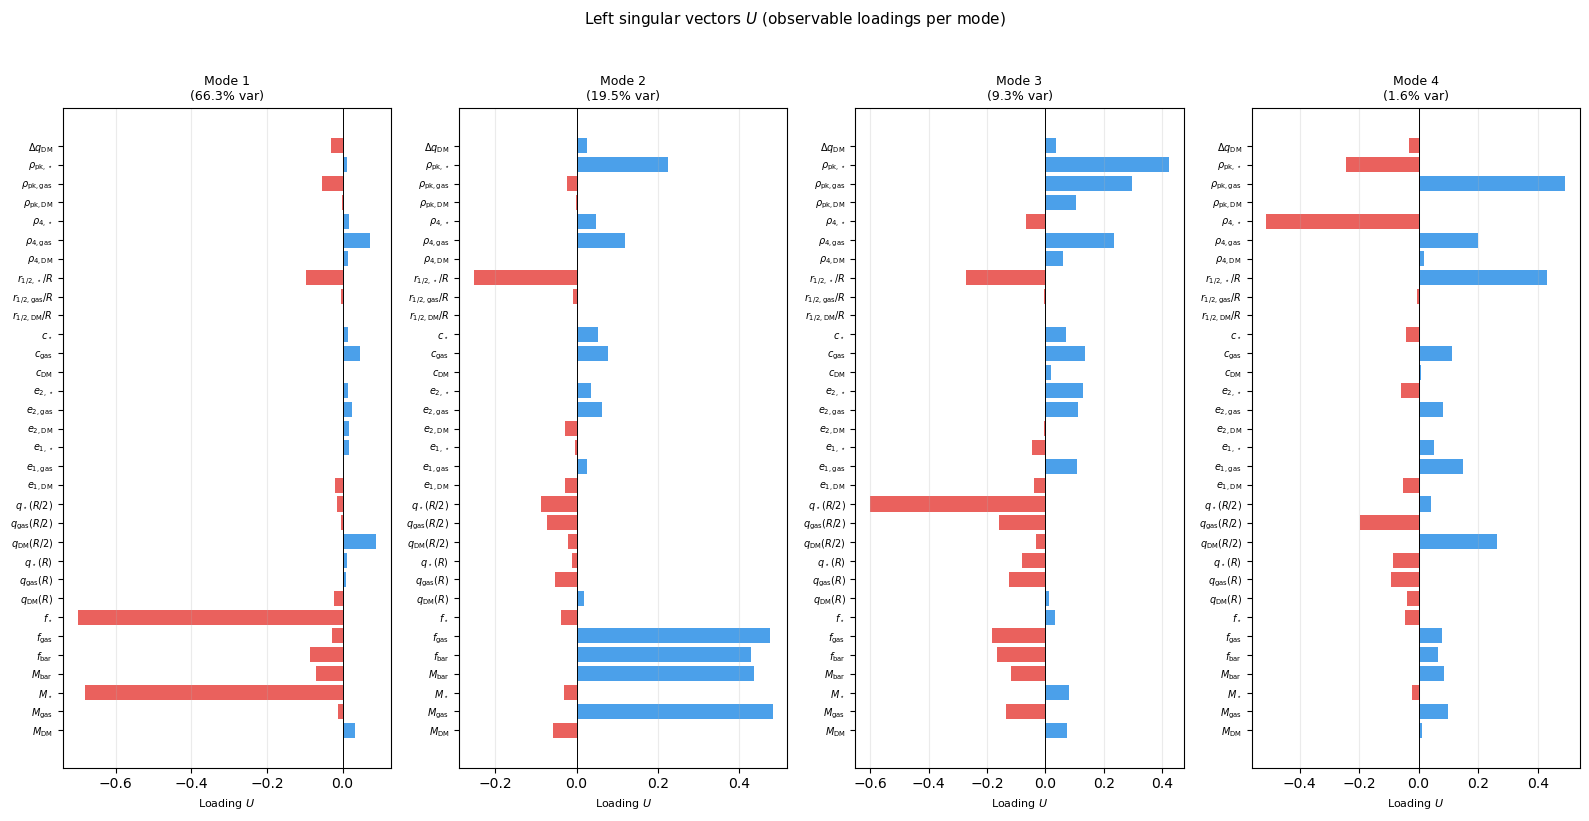

In [16]:
obs_labels_svd = [KEY_LATEX[k] for k in OBS_SVD_KEYS]
fig, axes = plt.subplots(1, N_SHOW, figsize=(4*N_SHOW, max(6, len(OBS_SVD_KEYS)*0.25)),
                          sharey=False)
for mi in range(N_SHOW):
    ax = axes[mi]
    u  = U[:, mi]
    colors_u = ['#E53935' if v < 0 else '#1E88E5' for v in u]
    ax.barh(range(len(OBS_SVD_KEYS)), u, color=colors_u, alpha=0.8)
    ax.set_yticks(range(len(OBS_SVD_KEYS)))
    ax.set_yticklabels(obs_labels_svd, fontsize=7)
    ax.axvline(0, color='k', lw=0.7)
    ax.set_title(f'Mode {mi+1}\n({var_expl[mi]:.1%} var)', fontsize=9)
    ax.set_xlabel('Loading $U$', fontsize=8)
    ax.grid(axis='x', alpha=0.25)
fig.suptitle('Left singular vectors $U$ (observable loadings per mode)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


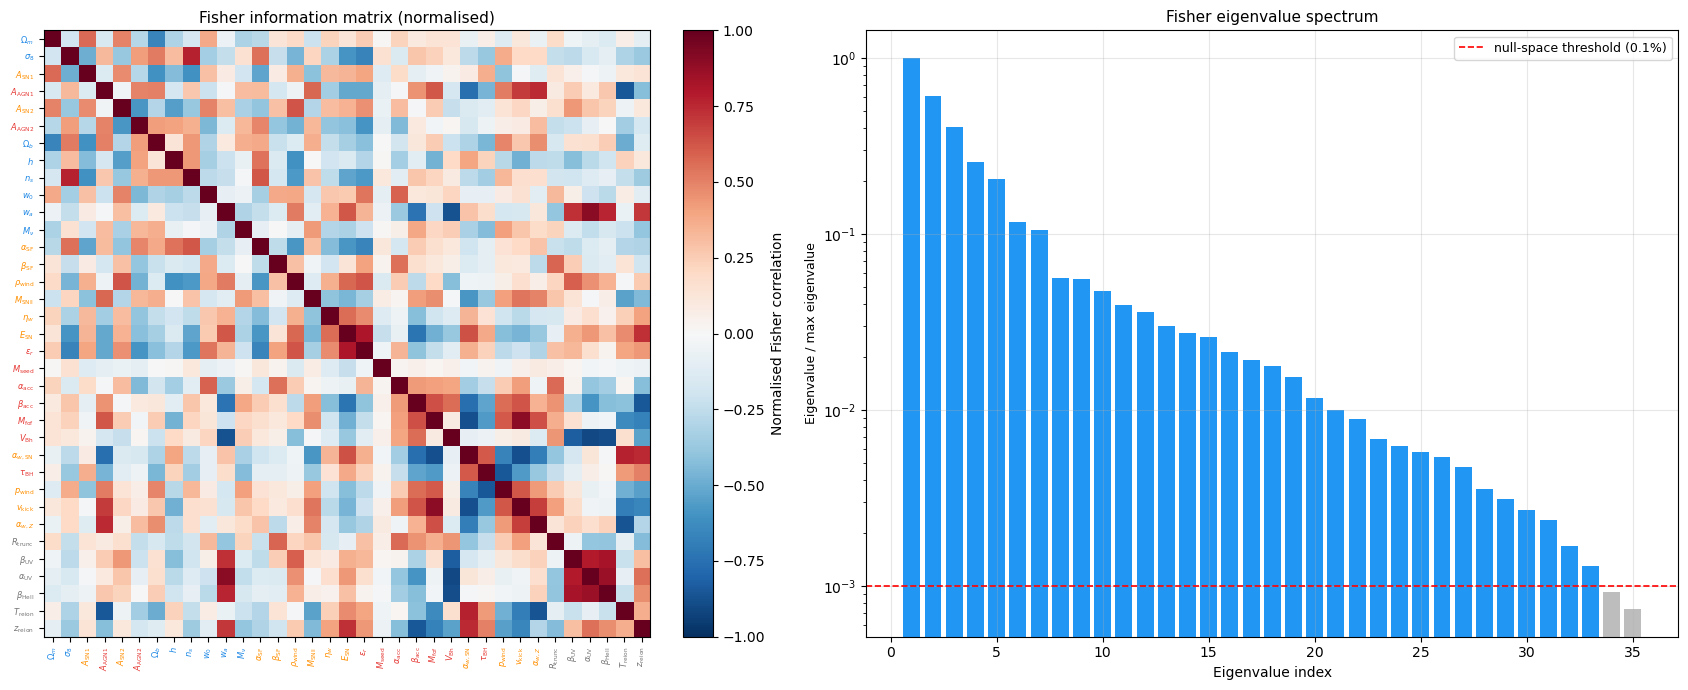

33/35 parameters above null-space threshold (detectable)
Null-space dimension: 2

Top-10 most detectable parameters:
  $A_{\rm SN1}$           detect=1.0000  group=SN
  $\tau_{\rm BH}$         detect=0.9636  group=AGN
  $M_\nu$                 detect=0.9577  group=cosmo
  $\Omega_m$              detect=0.9157  group=cosmo
  $\Omega_b$              detect=0.8636  group=cosmo
  $A_{\rm SN2}$           detect=0.8330  group=SN
  $p_{\rm wind}$          detect=0.7523  group=SN
  $M_{\rm SNII}$          detect=0.6631  group=SN
  $n_s$                   detect=0.5951  group=cosmo
  $\rho_{\rm wind}$       detect=0.4687  group=SN


In [17]:
# Noise floor: halo-to-halo scatter of fiducial observable
sigma_k = {}
for k in OBS_SVD_KEYS:
    v = F_fid_arr[k]
    if k in LOG_POS_KEYS:
        fin = v[(v > 0) & np.isfinite(v)]
        sigma_k[k] = float(np.std(np.log10(fin))) if len(fin) >= 10 else np.nan
    else:
        fin = v[np.isfinite(v)]
        sigma_k[k] = float(np.std(fin)) if len(fin) >= 10 else np.nan

# Fisher: F_ij = Σ_h Σ_k (J_hki J_hkj) / σ_k²
J_tensor  = np.stack([J_view[k] for k in OBS_SVD_KEYS], axis=1)   # (N_USE, N_obs, 35)
inv_var   = np.array([1/sigma_k[k]**2 if np.isfinite(sigma_k.get(k, np.nan)) else 0.0
                      for k in OBS_SVD_KEYS])
J_clean   = np.nan_to_num(J_tensor, nan=0.0)
J_wt      = J_clean * np.sqrt(inv_var)[None, :, None]
F_fisher  = np.einsum('hki,hkj->ij', J_wt, J_wt)   # (35, 35)

diag_sqrt = np.sqrt(np.maximum(np.diag(F_fisher), 0))
diag_sqrt = np.where(diag_sqrt > 0, diag_sqrt, 1.0)
F_norm    = F_fisher / np.outer(diag_sqrt, diag_sqrt)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]
im = ax.imshow(F_norm, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalised Fisher correlation')
labels_p = [PRETTY.get(j, str(j)) for j in range(N_PARAMS)]
ax.set_xticks(range(N_PARAMS)); ax.set_yticks(range(N_PARAMS))
ax.set_xticklabels(labels_p, rotation=90, fontsize=6)
ax.set_yticklabels(labels_p, fontsize=6)
for tick, j in zip(ax.get_xticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
for tick, j in zip(ax.get_yticklabels(), range(N_PARAMS)):
    tick.set_color(GROUP_COLORS[PARAM_GROUP[j]])
ax.set_title('Fisher information matrix (normalised)', fontsize=11)

eigvals, _ = np.linalg.eigh(F_fisher)
eigvals    = eigvals[::-1]
ax2 = axes[1]
ax2.bar(range(1, N_PARAMS+1), eigvals/eigvals[0],
        color=['#2196F3' if v > 1e-3 else '#BDBDBD' for v in eigvals/eigvals[0]])
ax2.set_yscale('log')
ax2.axhline(1e-3, color='red', ls='--', lw=1.2, label='null-space threshold (0.1%)')
ax2.set_xlabel('Eigenvalue index', fontsize=10)
ax2.set_ylabel('Eigenvalue / max eigenvalue', fontsize=9)
ax2.set_title('Fisher eigenvalue spectrum', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_det = int((eigvals/eigvals[0] > 1e-3).sum())
print(f'{n_det}/{N_PARAMS} parameters above null-space threshold (detectable)')
print(f'Null-space dimension: {N_PARAMS - n_det}')

# Per-param detectability rank
detectability = np.diag(F_fisher) / np.diag(F_fisher).max()
rank_det = np.argsort(-detectability)
print('\nTop-10 most detectable parameters:')
for i in rank_det[:10]:
    print(f'  {PRETTY.get(i,i):22s}  detect={detectability[i]:.4f}  group={PARAM_GROUP[i]}')


## Observable–Observable Jacobian Correlations

The **Jacobian cosine similarity** $\rho_{ab} = \mathbf{j}_a \cdot \mathbf{j}_b / (|\mathbf{j}_a||\mathbf{j}_b|)$
measures how similarly two observables respond to parameter variations.
Computed per halo from the raw $\partial F / \partial \tilde\theta$ view (valid for signed observables too).


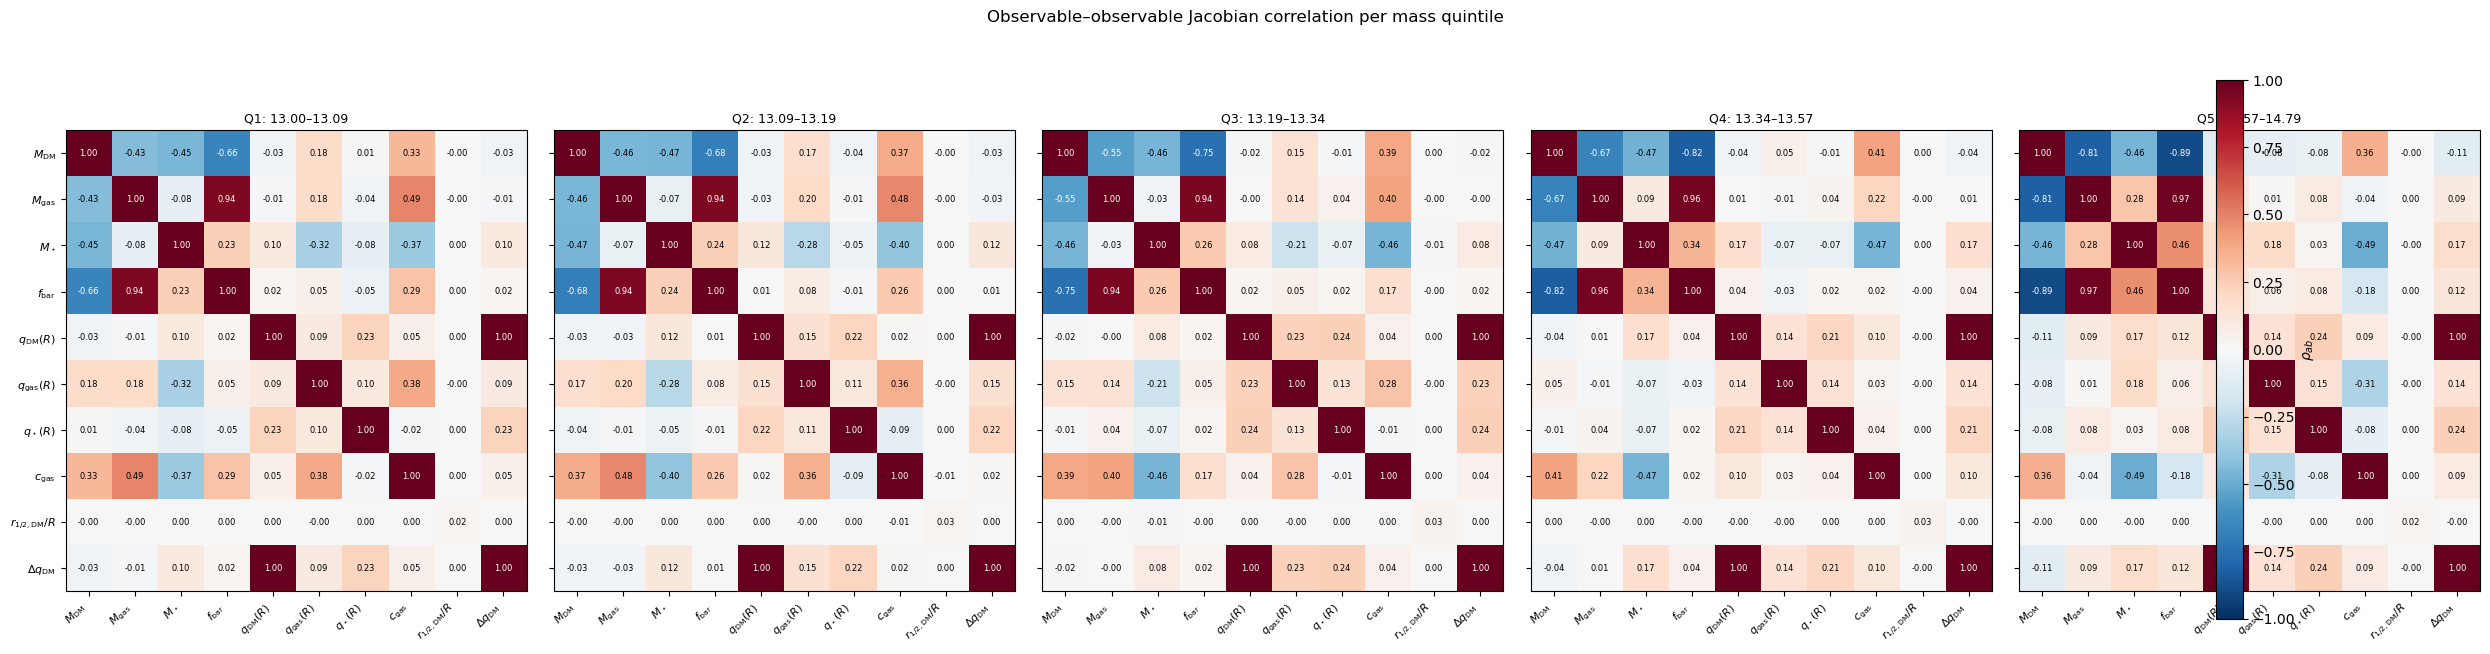

Overall mean Jacobian correlations (select pairs):
  M_gas        ↔ M_star        ρ = +0.036
  M_gas        ↔ f_bar         ρ = +0.950
  M_dm         ↔ M_gas         ρ = -0.584
  q_gas_R      ↔ q_star_R      ρ = +0.126
  conc_gas     ↔ rhalf_dm      ρ = +0.000


In [18]:
OBS_CORR_KEYS = [
    'M_dm','M_gas','M_star','f_bar',
    'q_dm_R','q_gas_R','q_star_R',
    'conc_gas','rhalf_dm','dq_dm',
]

J_corr_raw   = np.stack([J_obs_dnorm_all[k] for k in OBS_CORR_KEYS], axis=1)   # (N_USE, N_obs, 35)
J_corr_clean = np.nan_to_num(J_corr_raw, nan=0.0)
norms        = np.linalg.norm(J_corr_clean, axis=2, keepdims=True)
J_corr_norm  = np.where(norms > 0, J_corr_clean / norms, 0.0)
rho_corr     = np.einsum('haj,hbj->hab', J_corr_norm, J_corr_norm)   # (N_USE, N_obs, N_obs)

rho_by_bin = np.stack(
    [rho_corr[bin_idx == b].mean(axis=0) for b in range(N_MBINS)], axis=0
)   # (N_MBINS, N_obs, N_obs)

obs_corr_labels = [KEY_LATEX[k] for k in OBS_CORR_KEYS]
fig, axes = plt.subplots(1, N_MBINS, figsize=(5 * N_MBINS, 7))
for b, ax in enumerate(axes):
    mat = rho_by_bin[b]
    im  = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(OBS_CORR_KEYS)))
    ax.set_yticks(range(len(OBS_CORR_KEYS)))
    ax.set_xticklabels(obs_corr_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(obs_corr_labels if b == 0 else [], fontsize=8)
    ax.set_title(f'Q{b+1}: {MASS_LABELS[b]}', fontsize=9)
    for i in range(len(OBS_CORR_KEYS)):
        for j in range(len(OBS_CORR_KEYS)):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(mat[i,j]) > 0.5 else 'black')

fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label=r'$\rho_{ab}$')
fig.suptitle('Observable–observable Jacobian correlation per mass quintile', fontsize=12)
plt.tight_layout()
plt.show()

# Summary: print overall mean correlation
rho_mean = rho_corr.mean(axis=0)
print('Overall mean Jacobian correlations (select pairs):')
pairs = [('M_gas','M_star'),('M_gas','f_bar'),('M_dm','M_gas'),
         ('q_gas_R','q_star_R'),('conc_gas','rhalf_dm')]
oi = {k: i for i, k in enumerate(OBS_CORR_KEYS)}
for ka, kb in pairs:
    if ka in oi and kb in oi:
        print(f'  {ka:12s} ↔ {kb:12s}  ρ = {rho_mean[oi[ka],oi[kb]]:+.3f}')


## Jacobian-Linearized Inference for Group Scaling Relations

This section turns the population Jacobians into an explicit forward model and likelihood stack for parameter inference.

For each relation statistic $s \in \{\alpha,\beta,\sigma\}$ we use the local linearization around the fiducial point:

$$s(\tilde{\theta}) \approx s_0 + \mathbf{J}_s \cdot \delta\tilde{\theta}$$

with $\delta\tilde{\theta}$ in normalized-parameter coordinates (the same coordinates used by the FD Jacobians in this notebook).

We then implement:

1. Jacobian diagnostics and dominant-parameter summary.
2. A reusable linearized forward model for $(\alpha,\beta,\sigma)$.
3. Single-relation and joint multi-relation Gaussian likelihoods.
4. Fisher forecasts in physical-parameter space via $\mathbf{F}_\theta = \mathbf{J}^\top\mathbf{F}_s\mathbf{J}$.
5. Effective-dimensionality reduction (top-$k$ sensitive parameters).

### Mathematical Structure Used Below

We model each relation as

$$\log_{10} Y = \alpha(\tilde{\theta})\,\log_{10} M_{200c} + \beta(\tilde{\theta}) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0,\sigma^2(\tilde{\theta}))$$

with linearized summaries around the fiducial point

$$\alpha \approx \alpha_0 + \mathbf{J}_\alpha\cdot\delta\tilde{\theta},\quad
\beta \approx \beta_0 + \mathbf{J}_\beta\cdot\delta\tilde{\theta},\quad
\sigma \approx \sigma_0 + \mathbf{J}_\sigma\cdot\delta\tilde{\theta}.$$

For one relation, we use a Gaussian log-likelihood

$$\ln \mathcal{L} = -\frac{1}{2}\sum_i\left[\frac{(y_i-\mu_i)^2}{\sigma^2} + \ln(2\pi\sigma^2)\right], \qquad
\mu_i = \alpha\,x_i + \beta.$$

For summary vector $\mathbf{s}=(\alpha,\beta,\sigma)$ across all relations, we estimate $\mathbf{F}_s$ from bootstrap covariance and propagate to physical-parameter space with

$$\mathbf{F}_{\theta} = \mathbf{J}^\top\mathbf{F}_s\mathbf{J}.$$

We also build a reduced model by retaining the top-$k$ parameters that capture most Jacobian power, and a joint multi-relation likelihood with cross-relation covariance matrix $\mathbf{C}(\tilde{\theta})$.

In [23]:
# Build a compact relation registry that links each scaling relation to its Jacobian keys.
REL_SPECS = [
    {
        'rel': 'MgMs',
        'label': r'$M_{\\rm gas}$-$M_\\star$',
        'x_key': 'M_star',
        'y_key': 'M_gas',
        'keys': ('alpha_MgMs', 'beta_MgMs', 'sigma_MgMs'),
    },
    {
        'rel': 'MdMs',
        'label': r'$M_{\\rm DM}$-$M_\\star$',
        'x_key': 'M_star',
        'y_key': 'M_dm',
        'keys': ('alpha_MdMs', 'beta_MdMs', 'sigma_MdMs'),
    },
    {
        'rel': 'SHMR',
        'label': r'SHMR ($M_\\star$-$M_{200c}$)',
        'x_key': 'M200',
        'y_key': 'M_star',
        'keys': ('alpha_SHMR', 'beta_SHMR', 'sigma_SHMR'),
    },
    {
        'rel': 'GasFr',
        'label': r'$M_{\\rm gas}$-$M_{200c}$',
        'x_key': 'M200',
        'y_key': 'M_gas',
        'keys': ('alpha_GasFr', 'beta_GasFr', 'sigma_GasFr'),
    },
    {
        'rel': 'BarFr',
        'label': r'$M_{\\rm bar}$-$M_{200c}$',
        'x_key': 'M200',
        'y_key': 'M_bar',
        'keys': ('alpha_BarFr', 'beta_BarFr', 'sigma_BarFr'),
    },
]

POP_STAT_KEYS = [k for spec in REL_SPECS for k in spec['keys']]
J_POP_MATRIX = np.vstack([Jpop[k] for k in POP_STAT_KEYS])  # (15, 35)

def _top_params(vec, n=4):
    idx = np.argsort(-np.abs(vec))[:n]
    return [
        (int(j), PRETTY.get(int(j), str(int(j))), float(vec[j]), PARAM_GROUP[int(j)])
        for j in idx
    ]

print('--- Jacobian synthesis summary ---')

# 1) M_bar and M_gas relation Jacobians should be very similar at group scale.
pair_checks = [
    ('alpha_GasFr', 'alpha_BarFr', 'alpha'),
    ('beta_GasFr',  'beta_BarFr',  'beta'),
    ('sigma_GasFr', 'sigma_BarFr', 'sigma'),
]
for ka, kb, stat_name in pair_checks:
    va, vb = Jpop[ka], Jpop[kb]
    denom = (np.linalg.norm(va) * np.linalg.norm(vb))
    corr = float(np.dot(va, vb) / denom) if denom > 0 else np.nan
    rel_l2 = float(np.linalg.norm(va - vb) / (np.linalg.norm(va) + 1e-12))
    print(f'GasFr vs BarFr ({stat_name}): cosine={corr:+.3f}, rel_L2_diff={rel_l2:.3f}')

# 2) Top drivers per relation/statistic.
for spec in REL_SPECS:
    print(f"\\n{spec['rel']}  {spec['label']}")
    for k in spec['keys']:
        top = _top_params(Jpop[k], n=3)
        desc = ', '.join([f"{name} ({val:+.3f}, {grp})" for _, name, val, grp in top])
        print(f'  {k:12s} -> {desc}')

# 3) SHMR contrast with gas and baryon relations.
top_shmr = [j for j, _, _, _ in _top_params(Jpop['alpha_SHMR'], n=5)]
top_gas  = [j for j, _, _, _ in _top_params(Jpop['alpha_GasFr'], n=5)]
top_bar  = [j for j, _, _, _ in _top_params(Jpop['alpha_BarFr'], n=5)]
print('\nOverlap in top-5 slope drivers:')
print(f"  SHMR vs GasFr: {len(set(top_shmr).intersection(top_gas))}/5")
print(f"  SHMR vs BarFr: {len(set(top_shmr).intersection(top_bar))}/5")

# 4) Scatter sensitivity scale relative to slope/intercept.
sigma_rows = [i for i, k in enumerate(POP_STAT_KEYS) if k.startswith('sigma_')]
mean_rows  = [i for i, k in enumerate(POP_STAT_KEYS) if (k.startswith('alpha_') or k.startswith('beta_'))]
sigma_scale = float(np.nanmedian(np.abs(J_POP_MATRIX[sigma_rows])))
mean_scale  = float(np.nanmedian(np.abs(J_POP_MATRIX[mean_rows])))
ratio_scale = sigma_scale / (mean_scale + 1e-12)
print(f"\\nMedian |d sigma / d theta| = {sigma_scale:.4f}")
print(f"Median |d(alpha,beta) / d theta| = {mean_scale:.4f}")
print(f"Scale ratio sigma / (alpha,beta) = {ratio_scale:.3f}")

# 5) Effective dimensionality: parameters carrying most Jacobian power.
param_sens = np.linalg.norm(J_POP_MATRIX, axis=0)
power = param_sens**2
power_tot = float(power.sum())
if power_tot > 0:
    order = np.argsort(-param_sens)
    cum_power = np.cumsum(power[order]) / power_tot
    k90 = int(np.searchsorted(cum_power, 0.90) + 1)
else:
    order = np.arange(N_PARAMS)
    cum_power = np.zeros(N_PARAMS)
    k90 = N_PARAMS

TOP_PARAM_ORDER = order
TOP_PARAM_SENS = param_sens
K90 = k90

print(f"\\nEffective dimension for 90% Jacobian power: k90 = {K90}")
print('Top-10 parameters by aggregate sensitivity:')
for rank, j in enumerate(TOP_PARAM_ORDER[:10], start=1):
    print(
        f"  {rank:2d}. {PRETTY.get(int(j), str(int(j))):22s} "
        f"sens={TOP_PARAM_SENS[j]:.4f}  group={PARAM_GROUP[int(j)]}"
    )

--- Jacobian synthesis summary ---
GasFr vs BarFr (alpha): cosine=+0.988, rel_L2_diff=0.208
GasFr vs BarFr (beta): cosine=+0.986, rel_L2_diff=0.219
GasFr vs BarFr (sigma): cosine=+0.986, rel_L2_diff=0.254
\nMgMs  $M_{\\rm gas}$-$M_\\star$
  alpha_MgMs   -> $M_{\rm SNII}$ (+0.340, SN), $A_{\rm SN1}$ (-0.302, SN), $A_{\rm SN2}$ (-0.289, SN)
  beta_MgMs    -> $M_{\rm SNII}$ (-4.575, SN), $A_{\rm SN1}$ (+4.465, SN), $A_{\rm SN2}$ (+4.337, SN)
  sigma_MgMs   -> $A_{\rm SN2}$ (-0.051, SN), $M_\nu$ (+0.050, cosmo), $A_{\rm AGN2}$ (+0.031, AGN)
\nMdMs  $M_{\\rm DM}$-$M_\\star$
  alpha_MdMs   -> $M_{\rm SNII}$ (+0.130, SN), $\tau_{\rm BH}$ (+0.100, AGN), $A_{\rm SN2}$ (-0.085, SN)
  beta_MdMs    -> $M_{\rm SNII}$ (-1.914, SN), $\tau_{\rm BH}$ (-1.669, AGN), $A_{\rm SN2}$ (+1.652, SN)
  sigma_MdMs   -> $\eta_w$ (+0.026, SN), $A_{\rm SN1}$ (+0.026, SN), $n_s$ (-0.021, cosmo)
\nSHMR  SHMR ($M_\\star$-$M_{200c}$)
  alpha_SHMR   -> $\tau_{\rm BH}$ (-0.108, AGN), $M_{\rm SNII}$ (-0.102, SN), $A_{\rm 

In [20]:
def get_log_feature(feature_key):
    if feature_key == 'M200':
        raw = masses_use
    else:
        raw = F_fid_arr[feature_key]
    raw = np.asarray(raw, dtype=np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(raw > 0, np.log10(raw), np.nan)

def fit_scaling_stats(x_log, y_log, min_points=100):
    fin = np.isfinite(x_log) & np.isfinite(y_log)
    n = int(fin.sum())
    if n < min_points:
        return np.nan, np.nan, np.nan, n
    x = x_log[fin]
    y = y_log[fin]
    alpha, beta = np.polyfit(x, y, 1)
    resid = y - (alpha * x + beta)
    sigma = float(np.nanstd(resid, ddof=1)) if len(resid) > 1 else np.nan
    return float(alpha), float(beta), sigma, n

# Fit fiducial scaling-relation summaries from generated halos at theta_0.
fid_stats = {}
for spec in REL_SPECS:
    x_log = get_log_feature(spec['x_key'])
    y_log = get_log_feature(spec['y_key'])
    alpha0, beta0, sigma0, nfit = fit_scaling_stats(x_log, y_log, min_points=100)
    fid_stats[spec['rel']] = {
        'alpha': alpha0,
        'beta': beta0,
        'sigma': sigma0,
        'n': nfit,
    }

print('--- Fiducial scaling-relation fits (from generated halos) ---')
for spec in REL_SPECS:
    fs = fid_stats[spec['rel']]
    print(
        f"{spec['rel']:6s} n={fs['n']:4d}  "
        f"alpha0={fs['alpha']:+.4f}  beta0={fs['beta']:+.4f}  sigma0={fs['sigma']:.4f}"
    )

REL_BY_ID = {spec['rel']: spec for spec in REL_SPECS}

def relation_linearized_stats(delta_theta_norm, rel_id, clip_sigma=True):
    delta = np.asarray(delta_theta_norm, dtype=np.float64)
    if delta.shape != (N_PARAMS,):
        raise ValueError(f'delta_theta_norm must have shape ({N_PARAMS},), got {delta.shape}')

    spec = REL_BY_ID[rel_id]
    fs = fid_stats[rel_id]
    k_alpha, k_beta, k_sigma = spec['keys']

    alpha = fs['alpha'] + float(np.dot(Jpop[k_alpha], delta))
    beta = fs['beta'] + float(np.dot(Jpop[k_beta], delta))
    sigma = fs['sigma'] + float(np.dot(Jpop[k_sigma], delta))
    if clip_sigma:
        sigma = float(np.clip(sigma, 1e-3, None))
    return alpha, beta, sigma

def all_linearized_stats(delta_theta_norm):
    out = {}
    for spec in REL_SPECS:
        out[spec['rel']] = relation_linearized_stats(delta_theta_norm, spec['rel'])
    return out

# Baseline vector s0 and Jacobian matrix J used in Fisher propagation.
S0_VECTOR = np.array(
    [fid_stats[spec['rel']][stat] for spec in REL_SPECS for stat in ('alpha', 'beta', 'sigma')],
    dtype=np.float64,
)

print(f"\\nS0_VECTOR shape: {S0_VECTOR.shape} (expected 15)")
print(f"J_POP_MATRIX shape: {J_POP_MATRIX.shape} (15 x {N_PARAMS})")

--- Fiducial scaling-relation fits (from generated halos) ---
MgMs   n=1154  alpha0=+1.1434  beta0=-0.6195  sigma0=0.1063
MdMs   n=1154  alpha0=+0.9643  beta0=+2.3059  sigma0=0.0765
SHMR   n=1154  alpha0=+0.9638  beta0=-1.3491  sigma0=0.1247
GasFr  n=1154  alpha0=+1.1716  beta0=-3.0920  sigma0=0.1278
BarFr  n=1154  alpha0=+1.1536  beta0=-2.8111  sigma0=0.1243
\nS0_VECTOR shape: (15,) (expected 15)
J_POP_MATRIX shape: (15, 35) (15 x 35)


In [21]:
# Prepare per-relation arrays used by the Eq. (3) Gaussian likelihood.
REL_DATA = {}
for spec in REL_SPECS:
    rel = spec['rel']
    x_all = get_log_feature(spec['x_key'])
    y_all = get_log_feature(spec['y_key'])
    fin = np.isfinite(x_all) & np.isfinite(y_all)
    REL_DATA[rel] = {
        'x': x_all[fin],
        'y': y_all[fin],
        'n': int(fin.sum()),
    }

def relation_loglike(delta_theta_norm, rel_id):
    alpha, beta, sigma = relation_linearized_stats(delta_theta_norm, rel_id, clip_sigma=True)
    x = REL_DATA[rel_id]['x']
    y = REL_DATA[rel_id]['y']
    var = sigma**2
    mu = alpha * x + beta
    resid = y - mu
    return float(-0.5 * np.sum((resid**2) / var + np.log(2.0 * np.pi * var)))

delta0 = np.zeros(N_PARAMS, dtype=np.float64)
print('--- Baseline per-relation log-likelihood at delta_theta = 0 ---')
for spec in REL_SPECS:
    rel = spec['rel']
    ll0 = relation_loglike(delta0, rel)
    print(f"{rel:6s}  n={REL_DATA[rel]['n']:4d}  logL0={ll0: .2f}")

# Bootstrap covariance in summary-stat space s = (alpha, beta, sigma)x5.
N_BOOT = 300
rng = np.random.default_rng(2026)
boot_vecs = []
for _ in range(N_BOOT):
    vec = []
    ok = True
    for spec in REL_SPECS:
        rel = spec['rel']
        x = REL_DATA[rel]['x']
        y = REL_DATA[rel]['y']
        if len(x) < 50:
            ok = False
            break
        draw = rng.integers(0, len(x), size=len(x))
        a, b, s, _ = fit_scaling_stats(x[draw], y[draw], min_points=50)
        if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(s)):
            ok = False
            break
        vec.extend([a, b, s])
    if ok:
        boot_vecs.append(vec)

boot_arr = np.asarray(boot_vecs, dtype=np.float64)
print(f"\nBootstrap draws kept: {len(boot_arr)}/{N_BOOT}")

if boot_arr.shape[0] >= 2:
    C_s = np.cov(boot_arr, rowvar=False)
else:
    C_s = np.eye(len(S0_VECTOR), dtype=np.float64) * 1e-3

diag_med = float(np.nanmedian(np.diag(C_s))) if C_s.size else 0.0
if not np.isfinite(diag_med) or diag_med <= 0:
    diag_med = 1e-6
jitter = (1e-6 * diag_med + 1e-10) * np.eye(C_s.shape[0], dtype=np.float64)
C_s_reg = C_s + jitter
F_s = np.linalg.pinv(C_s_reg, rcond=1e-10)

# Eq. (7): Fisher in physical-parameter space from Jacobian propagation.
F_theta = J_POP_MATRIX.T @ F_s @ J_POP_MATRIX
F_theta = 0.5 * (F_theta + F_theta.T)
C_theta = np.linalg.pinv(F_theta, rcond=1e-10)
theta_sigma = np.sqrt(np.clip(np.diag(C_theta), 0.0, np.inf))

det_score = np.diag(F_theta).copy()
det_max = float(np.nanmax(det_score)) if np.isfinite(det_score).any() else 0.0
detectability = det_score / det_max if det_max > 0 else np.zeros_like(det_score)
rank_det = np.argsort(-detectability)

print('\nTop-10 parameters by Fisher detectability (diag-normalized):')
for i in rank_det[:10]:
    print(
        f"  {PRETTY.get(int(i), str(int(i))):22s} "
        f"detect={detectability[i]:.4f}  sigma_CRLB={theta_sigma[i]:.4e}  group={PARAM_GROUP[int(i)]}"
    )

# Persist for downstream diagnostics/plots.
C_s_REG = C_s_reg
F_s_STAT = F_s
F_theta_STAT = F_theta
C_theta_STAT = C_theta
THETA_SIGMA = theta_sigma
DETECTABILITY_SCORE = detectability

--- Baseline per-relation log-likelihood at delta_theta = 0 ---
MgMs    n=1154  logL0= 949.77
MdMs    n=1154  logL0= 1328.90
SHMR    n=1154  logL0= 765.22
GasFr   n=1154  logL0= 737.05
BarFr   n=1154  logL0= 768.85

Bootstrap draws kept: 300/300

Top-10 parameters by Fisher detectability (diag-normalized):
  $\Omega_m$             detect=1.0000  sigma_CRLB=2.0050e+00  group=cosmo
  $A_{\rm SN2}$          detect=0.9308  sigma_CRLB=9.6812e+00  group=SN
  $A_{\rm SN1}$          detect=0.8849  sigma_CRLB=9.6551e+00  group=SN
  $\tau_{\rm BH}$        detect=0.4120  sigma_CRLB=4.3552e+00  group=AGN
  $M_{\rm SNII}$         detect=0.3902  sigma_CRLB=5.1659e+00  group=SN
  $\Omega_b$             detect=0.2668  sigma_CRLB=3.6378e+00  group=cosmo
  $h$                    detect=0.2409  sigma_CRLB=3.7837e+00  group=cosmo
  $\alpha_{\rm SF}$      detect=0.2197  sigma_CRLB=7.8883e+00  group=SN
  $M_\nu$                detect=0.1773  sigma_CRLB=6.9281e+00  group=cosmo
  $\rho_{\rm wind}$      detect

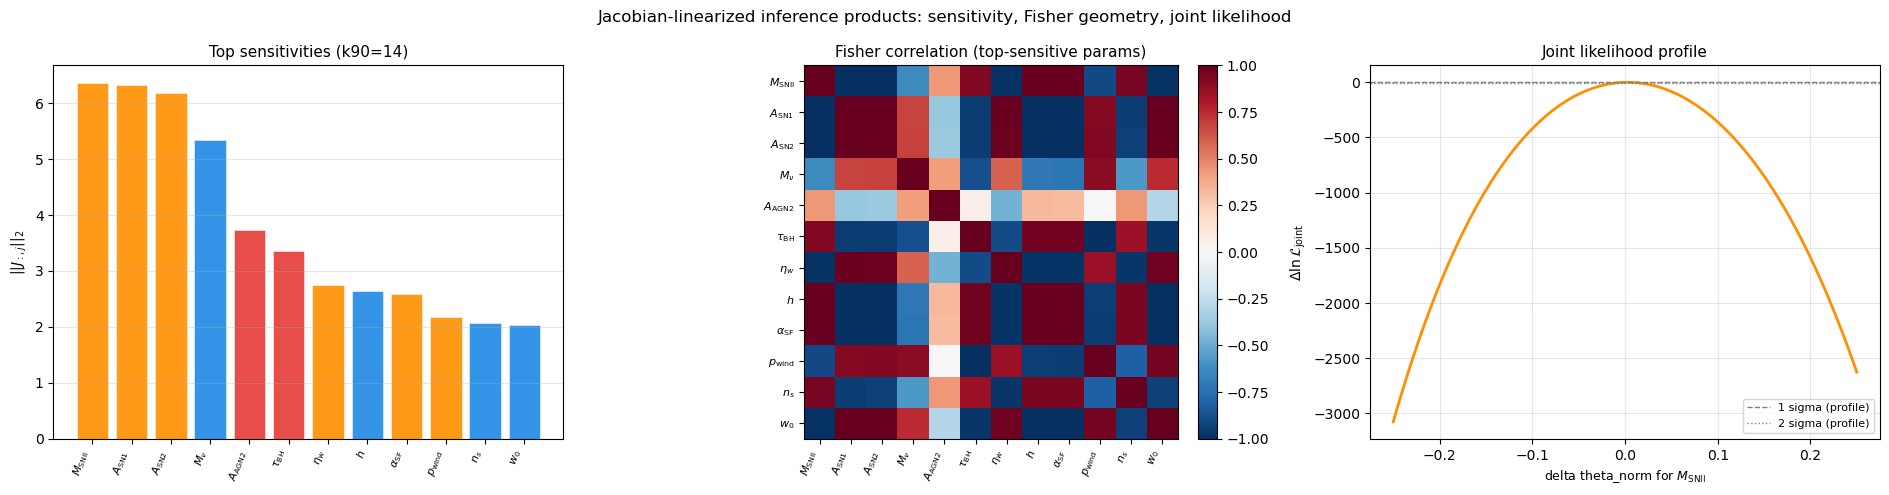

--- Joint-likelihood and Fisher summary ---
Joint halo count: 1154/1154
Effective dimensionality (90% Jacobian power): k90=14
Detectable Fisher directions (>1e-3 of max eigenvalue): 4/35

Top reduced-space constraints (k90 subspace):
   1. $M_{\rm SNII}$         sigma_CRLB=4.2330e+00
   2. $A_{\rm SN1}$          sigma_CRLB=5.2242e+00
   3. $A_{\rm SN2}$          sigma_CRLB=2.7372e+00
   4. $M_\nu$                sigma_CRLB=2.2202e+00
   5. $A_{\rm AGN2}$         sigma_CRLB=2.3690e+00
   6. $\tau_{\rm BH}$        sigma_CRLB=3.9458e+00
   7. $\eta_w$               sigma_CRLB=3.4514e+00
   8. $h$                    sigma_CRLB=7.8291e+00
   9. $\alpha_{\rm SF}$      sigma_CRLB=6.1420e+00
  10. $p_{\rm wind}$         sigma_CRLB=3.4840e+00

Suggested observational tests and Jacobian leverage:
  eROSITA/ACT slope test (AGN): dalpha_BarFr/dtheta=+0.1432 for $A_{\rm AGN2}$
  SHMR normalization test (Omega_b): dbeta_SHMR/dtheta=-0.4361 for $\Omega_b$
  Mbar scatter environment test (SN1): dsigma

In [22]:
# Build a joint halo sample where all relation inputs are finite.
joint_mask = np.ones(N_USE, dtype=bool)
x_cache_all, y_cache_all = {}, {}
for spec in REL_SPECS:
    rel = spec['rel']
    x_all = get_log_feature(spec['x_key'])
    y_all = get_log_feature(spec['y_key'])
    x_cache_all[rel] = x_all
    y_cache_all[rel] = y_all
    joint_mask &= np.isfinite(x_all) & np.isfinite(y_all)

REL_ORDER = [spec['rel'] for spec in REL_SPECS]
X_joint = np.column_stack([x_cache_all[rel][joint_mask] for rel in REL_ORDER])
Y_joint = np.column_stack([y_cache_all[rel][joint_mask] for rel in REL_ORDER])

# Fiducial residual covariance across relations (captures cross-channel covariance).
alpha0_vec = np.array([fid_stats[rel]['alpha'] for rel in REL_ORDER], dtype=np.float64)
beta0_vec = np.array([fid_stats[rel]['beta'] for rel in REL_ORDER], dtype=np.float64)
sigma0_vec = np.array([fid_stats[rel]['sigma'] for rel in REL_ORDER], dtype=np.float64)
MU0 = alpha0_vec[None, :] * X_joint + beta0_vec[None, :]
R0 = Y_joint - MU0
C0 = np.cov(R0, rowvar=False)
C0 = 0.5 * (C0 + C0.T)
diag_med_c0 = float(np.nanmedian(np.diag(C0))) if C0.size else 0.0
if not np.isfinite(diag_med_c0) or diag_med_c0 <= 0:
    diag_med_c0 = 1e-6
C0 = C0 + (1e-6 * diag_med_c0 + 1e-10) * np.eye(C0.shape[0], dtype=np.float64)

def joint_loglike(delta_theta_norm):
    delta = np.asarray(delta_theta_norm, dtype=np.float64)
    if delta.shape != (N_PARAMS,):
        raise ValueError(f'delta_theta_norm must have shape ({N_PARAMS},), got {delta.shape}')

    alpha_vec, beta_vec, sigma_vec = [], [], []
    for rel in REL_ORDER:
        a, b, s = relation_linearized_stats(delta, rel, clip_sigma=True)
        alpha_vec.append(a)
        beta_vec.append(b)
        sigma_vec.append(s)
    alpha_vec = np.asarray(alpha_vec, dtype=np.float64)
    beta_vec = np.asarray(beta_vec, dtype=np.float64)
    sigma_vec = np.asarray(sigma_vec, dtype=np.float64)

    mu = alpha_vec[None, :] * X_joint + beta_vec[None, :]
    resid = Y_joint - mu

    # Parameter-dependent covariance model via sigma rescaling around the fiducial covariance.
    scale = np.clip(sigma_vec / np.clip(sigma0_vec, 1e-6, None), 0.25, 4.0)
    D = np.diag(scale)
    C_theta = D @ C0 @ D
    C_theta = 0.5 * (C_theta + C_theta.T) + 1e-10 * np.eye(C_theta.shape[0], dtype=np.float64)

    sign, logdet = np.linalg.slogdet(C_theta)
    if sign <= 0:
        return -np.inf

    invC = np.linalg.pinv(C_theta, rcond=1e-12)
    quad = np.einsum('ni,ij,nj->n', resid, invC, resid)
    n_rel = C_theta.shape[0]
    return float(-0.5 * np.sum(quad + logdet + n_rel * np.log(2.0 * np.pi)))

# Reduced-space Fisher model using top-k sensitive parameters (Eq. 5 idea).
k_use = max(1, int(K90))
idx_red = TOP_PARAM_ORDER[:k_use]
J_reduced = J_POP_MATRIX[:, idx_red]
F_theta_red = J_reduced.T @ F_s_STAT @ J_reduced
F_theta_red = 0.5 * (F_theta_red + F_theta_red.T)
C_theta_red = np.linalg.pinv(F_theta_red, rcond=1e-10)
sigma_red = np.sqrt(np.clip(np.diag(C_theta_red), 0.0, np.inf))

# Profile the joint likelihood along the single most sensitive parameter.
j_star = int(TOP_PARAM_ORDER[0]) if len(TOP_PARAM_ORDER) > 0 else 0
scan = np.linspace(-0.25, 0.25, 101)
ll_scan = []
for t in scan:
    d = np.zeros(N_PARAMS, dtype=np.float64)
    d[j_star] = t
    ll_scan.append(joint_loglike(d))
ll_scan = np.asarray(ll_scan, dtype=np.float64)
dll_scan = ll_scan - np.nanmax(ll_scan)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Panel 1: Aggregate parameter sensitivity norm.
ax = axes[0]
topn = min(12, N_PARAMS)
idx_plot = TOP_PARAM_ORDER[:topn]
vals = TOP_PARAM_SENS[idx_plot]
colors = [GROUP_COLORS[PARAM_GROUP[int(j)]] for j in idx_plot]
ax.bar(np.arange(topn), vals, color=colors, alpha=0.9, edgecolor='white', lw=0.4)
ax.set_xticks(np.arange(topn))
ax.set_xticklabels([PRETTY.get(int(j), str(int(j))) for j in idx_plot], rotation=70, ha='right', fontsize=8)
ax.set_title(f'Top sensitivities (k90={K90})', fontsize=11)
ax.set_ylabel(r'$||J_{:,j}||_2$', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Fisher correlation in top sensitive subspace.
ax = axes[1]
F_sub = F_theta_STAT[np.ix_(idx_plot, idx_plot)]
den = np.sqrt(np.outer(np.diag(F_sub), np.diag(F_sub)))
with np.errstate(divide='ignore', invalid='ignore'):
    Corr_sub = np.where(den > 0, F_sub / den, 0.0)
im = ax.imshow(Corr_sub, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(topn)); ax.set_yticks(np.arange(topn))
lab_sub = [PRETTY.get(int(j), str(int(j))) for j in idx_plot]
ax.set_xticklabels(lab_sub, rotation=70, ha='right', fontsize=8)
ax.set_yticklabels(lab_sub, fontsize=8)
ax.set_title('Fisher correlation (top-sensitive params)', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Panel 3: Joint profile likelihood slice.
ax = axes[2]
ax.plot(scan, dll_scan, color=GROUP_COLORS[PARAM_GROUP[j_star]], lw=2)
ax.axhline(-0.5, color='gray', ls='--', lw=1, label='1 sigma (profile)')
ax.axhline(-2.0, color='gray', ls=':', lw=1, label='2 sigma (profile)')
ax.set_xlabel(f"delta theta_norm for {PRETTY.get(j_star, str(j_star))}", fontsize=9)
ax.set_ylabel(r'$\Delta \ln \mathcal{L}_{\rm joint}$', fontsize=10)
ax.set_title('Joint likelihood profile', fontsize=11)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

fig.suptitle('Jacobian-linearized inference products: sensitivity, Fisher geometry, joint likelihood', fontsize=12)
plt.tight_layout()
plt.show()

eigvals = np.linalg.eigvalsh(F_theta_STAT)[::-1]
eig_rel = eigvals / eigvals[0] if (len(eigvals) > 0 and eigvals[0] > 0) else np.zeros_like(eigvals)
n_det = int(np.sum(eig_rel > 1e-3))

print('--- Joint-likelihood and Fisher summary ---')
print(f'Joint halo count: {int(joint_mask.sum())}/{N_USE}')
print(f'Effective dimensionality (90% Jacobian power): k90={K90}')
print(f'Detectable Fisher directions (>1e-3 of max eigenvalue): {n_det}/{N_PARAMS}')

print('\nTop reduced-space constraints (k90 subspace):')
for local_rank, (j, sigj) in enumerate(zip(idx_red[:10], sigma_red[:10]), start=1):
    print(f"  {local_rank:2d}. {PRETTY.get(int(j), str(int(j))):22s} sigma_CRLB={sigj:.4e}")

# A compact test matrix directly tied to high-value Jacobian entries.
test_rows = [
    ('eROSITA/ACT slope test (AGN)', 'alpha_BarFr', 5),
    ('SHMR normalization test (Omega_b)', 'beta_SHMR', 6),
    ('Mbar scatter environment test (SN1)', 'sigma_BarFr', 2),
]
print('\nSuggested observational tests and Jacobian leverage:')
for label, key, pidx in test_rows:
    print(
        f"  {label}: d{key}/dtheta={Jpop[key][pidx]:+.4f} "
        f"for {PRETTY.get(pidx, str(pidx))}"
    )

## Continuation: 28-Parameter Projection and Artifact Export

This continuation block does two things:

1. Adds explicit parameter-subspace projections, including a 28-parameter mode for TNG-focused analyses.
2. Saves the Jacobian-linearized inference objects (Fisher matrices, covariance, profiles, rankings) to disk for paper tables and downstream scripts.

The 28-parameter mode is configurable via an explicit index list so you can match your preferred CAMELS/TNG convention exactly.

--- Projection summary ---
all35       n_params=35  detectable_dirs= 4  cond_proxy=-3.873e-17
tng28       n_params=28  detectable_dirs= 4  cond_proxy=-3.338e-17
no_other29  n_params=29  detectable_dirs= 4  cond_proxy=-3.151e-17

Top-10 tng28 detectability ranking:
  $A_{\rm SN2}$          detect=1.0000  sigma_CRLB=1.0852e+01  group=SN
  $A_{\rm SN1}$          detect=0.9507  sigma_CRLB=9.4818e+00  group=SN
  $\tau_{\rm BH}$        detect=0.4427  sigma_CRLB=3.5306e+00  group=AGN
  $M_{\rm SNII}$         detect=0.4192  sigma_CRLB=8.8578e+00  group=SN
  $\alpha_{\rm SF}$      detect=0.2360  sigma_CRLB=1.0478e+01  group=SN
  $M_\nu$                detect=0.1905  sigma_CRLB=5.8653e+00  group=cosmo
  $\rho_{\rm wind}$      detect=0.1860  sigma_CRLB=5.7756e+00  group=SN
  $\beta_{\rm acc}$      detect=0.1092  sigma_CRLB=3.9638e+01  group=AGN
  $M_{\rm fof}$          detect=0.0938  sigma_CRLB=2.1644e+01  group=AGN
  $E_{\rm SN}$           detect=0.0938  sigma_CRLB=9.4322e+00  group=SN


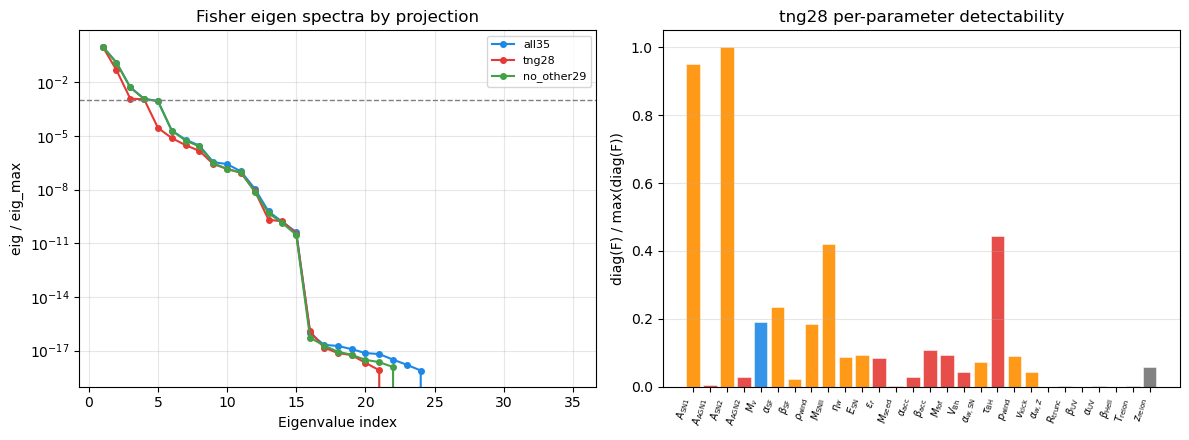

In [25]:
def fisher_projection(param_idx, name='subspace'):
    idx = np.asarray(param_idx, dtype=int)
    J_sub = J_POP_MATRIX[:, idx]
    F_sub = J_sub.T @ F_s_STAT @ J_sub
    F_sub = 0.5 * (F_sub + F_sub.T)
    C_sub = np.linalg.pinv(F_sub, rcond=1e-10)
    sigma_sub = np.sqrt(np.clip(np.diag(C_sub), 0.0, np.inf))
    det = np.diag(F_sub).copy()
    det = det / det.max() if (len(det) > 0 and np.nanmax(det) > 0) else np.zeros_like(det)
    eig = np.linalg.eigvalsh(F_sub)[::-1] if F_sub.size else np.array([])
    eig_rel = eig / eig[0] if (len(eig) > 0 and eig[0] > 0) else np.zeros_like(eig)
    n_det = int(np.sum(eig_rel > 1e-3)) if len(eig_rel) else 0
    rank = np.argsort(-det) if len(det) else np.array([], dtype=int)
    return {
        'name': name,
        'idx': idx,
        'F': F_sub,
        'C': C_sub,
        'sigma': sigma_sub,
        'det': det,
        'eig': eig,
        'eig_rel': eig_rel,
        'n_det': n_det,
        'rank': rank,
    }

# Parameter-space choices.
IDX_ALL35 = np.arange(N_PARAMS, dtype=int)

# 28-parameter proxy: remove seven standard background-cosmology entries.
# Adjust this list to match your exact TNG parameter convention if needed.
EXCLUDE_COSMO7 = np.array([0, 1, 6, 7, 8, 9, 10], dtype=int)
IDX_TNG28 = np.array([j for j in IDX_ALL35 if j not in EXCLUDE_COSMO7], dtype=int)

# Optional alternate projection: remove the six 'other' parameters.
IDX_NO_OTHER29 = np.array([j for j in IDX_ALL35 if PARAM_GROUP[int(j)] != 'other'], dtype=int)

PROJ = {
    'all35': fisher_projection(IDX_ALL35, name='all35'),
    'tng28': fisher_projection(IDX_TNG28, name='tng28'),
    'no_other29': fisher_projection(IDX_NO_OTHER29, name='no_other29'),
}

print('--- Projection summary ---')
for key in ['all35', 'tng28', 'no_other29']:
    p = PROJ[key]
    print(
        f"{key:10s}  n_params={len(p['idx']):2d}  "
        f"detectable_dirs={p['n_det']:2d}  cond_proxy={(p['eig_rel'][-1] if len(p['eig_rel']) else np.nan):.3e}"
    )

print('\nTop-10 tng28 detectability ranking:')
p = PROJ['tng28']
for rr in p['rank'][:10]:
    j = int(p['idx'][rr])
    print(
        f"  {PRETTY.get(j, str(j)):22s} "
        f"detect={p['det'][rr]:.4f}  sigma_CRLB={p['sigma'][rr]:.4e}  group={PARAM_GROUP[j]}"
    )

# Compare eigenvalue spectra between all35 and tng28.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for key, color in [('all35', '#1E88E5'), ('tng28', '#E53935'), ('no_other29', '#43A047')]:
    eig_rel = PROJ[key]['eig_rel']
    if len(eig_rel) > 0:
        ax.plot(np.arange(1, len(eig_rel) + 1), eig_rel, 'o-', lw=1.5, ms=4, label=key, color=color)
ax.set_yscale('log')
ax.axhline(1e-3, color='gray', ls='--', lw=1)
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('eig / eig_max')
ax.set_title('Fisher eigen spectra by projection')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
x = np.arange(len(PROJ['tng28']['idx']))
colors = [GROUP_COLORS[PARAM_GROUP[int(j)]] for j in PROJ['tng28']['idx']]
ax.bar(x, PROJ['tng28']['det'], color=colors, alpha=0.9, edgecolor='white', lw=0.4)
ax.set_xticks(x)
ax.set_xticklabels([PRETTY.get(int(j), str(int(j))) for j in PROJ['tng28']['idx']], rotation=75, ha='right', fontsize=7)
ax.set_ylabel('diag(F) / max(diag(F))')
ax.set_title('tng28 per-parameter detectability')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
from datetime import datetime

OUT_DIR = CACHE_DIR / 'jacobian_inference_artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reuse profile objects from the joint-likelihood cell when available.
scan_out = np.asarray(scan, dtype=np.float64) if 'scan' in globals() else np.linspace(-0.25, 0.25, 101)
if 'dll_scan' in globals():
    dll_out = np.asarray(dll_scan, dtype=np.float64)
else:
    dtmp = np.zeros(N_PARAMS, dtype=np.float64)
    jtmp = int(TOP_PARAM_ORDER[0]) if len(TOP_PARAM_ORDER) else 0
    vals = []
    for tt in scan_out:
        dtmp[:] = 0.0
        dtmp[jtmp] = tt
        vals.append(joint_loglike(dtmp))
    vals = np.asarray(vals, dtype=np.float64)
    dll_out = vals - np.nanmax(vals)

j_star_out = int(j_star) if 'j_star' in globals() else int(TOP_PARAM_ORDER[0])
idx_red_out = np.asarray(idx_red, dtype=int) if 'idx_red' in globals() else np.asarray(TOP_PARAM_ORDER[:K90], dtype=int)
sigma_red_out = np.asarray(sigma_red, dtype=np.float64) if 'sigma_red' in globals() else np.full(len(idx_red_out), np.nan)

stamp = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
npz_path = OUT_DIR / f'cv_scatter_jacobian_inference_{stamp}.npz'
latest_npz = OUT_DIR / 'cv_scatter_jacobian_inference_latest.npz'

np.savez(
    npz_path,
    stamp=stamp,
    s0=S0_VECTOR,
    j_pop=J_POP_MATRIX,
    c_s=C_s_REG,
    f_s=F_s_STAT,
    f_theta_all=F_theta_STAT,
    c_theta_all=C_theta_STAT,
    detectability_all=DETECTABILITY_SCORE,
    theta_sigma_all=THETA_SIGMA,
    top_param_order=TOP_PARAM_ORDER,
    top_param_sens=TOP_PARAM_SENS,
    k90=np.array([K90], dtype=int),
    idx_tng28=PROJ['tng28']['idx'],
    f_theta_tng28=PROJ['tng28']['F'],
    c_theta_tng28=PROJ['tng28']['C'],
    detectability_tng28=PROJ['tng28']['det'],
    theta_sigma_tng28=PROJ['tng28']['sigma'],
    idx_no_other29=PROJ['no_other29']['idx'],
    f_theta_no_other29=PROJ['no_other29']['F'],
    c_theta_no_other29=PROJ['no_other29']['C'],
    detectability_no_other29=PROJ['no_other29']['det'],
    theta_sigma_no_other29=PROJ['no_other29']['sigma'],
    rel_order=np.array(REL_ORDER, dtype='U16'),
    scan=scan_out,
    delta_loglike_profile=dll_out,
    profile_param_index=np.array([j_star_out], dtype=int),
    reduced_idx=idx_red_out,
    reduced_sigma=sigma_red_out,
)
np.savez(
    latest_npz,
    stamp=stamp,
    s0=S0_VECTOR,
    j_pop=J_POP_MATRIX,
    c_s=C_s_REG,
    f_s=F_s_STAT,
    f_theta_all=F_theta_STAT,
    c_theta_all=C_theta_STAT,
    detectability_all=DETECTABILITY_SCORE,
    theta_sigma_all=THETA_SIGMA,
    top_param_order=TOP_PARAM_ORDER,
    top_param_sens=TOP_PARAM_SENS,
    k90=np.array([K90], dtype=int),
    idx_tng28=PROJ['tng28']['idx'],
    f_theta_tng28=PROJ['tng28']['F'],
    c_theta_tng28=PROJ['tng28']['C'],
    detectability_tng28=PROJ['tng28']['det'],
    theta_sigma_tng28=PROJ['tng28']['sigma'],
    idx_no_other29=PROJ['no_other29']['idx'],
    f_theta_no_other29=PROJ['no_other29']['F'],
    c_theta_no_other29=PROJ['no_other29']['C'],
    detectability_no_other29=PROJ['no_other29']['det'],
    theta_sigma_no_other29=PROJ['no_other29']['sigma'],
    rel_order=np.array(REL_ORDER, dtype='U16'),
    scan=scan_out,
    delta_loglike_profile=dll_out,
    profile_param_index=np.array([j_star_out], dtype=int),
    reduced_idx=idx_red_out,
    reduced_sigma=sigma_red_out,
)

# Human-readable CSV summary for quick table use.
csv_path = OUT_DIR / 'cv_scatter_param_summary_latest.csv'
with open(csv_path, 'w', encoding='utf-8') as f:
    f.write('param_idx,label,group,detect_all,sigma_all,detect_tng28,sigma_tng28\n')
    tng_map = {int(j): ii for ii, j in enumerate(PROJ['tng28']['idx'])}
    for j in range(N_PARAMS):
        if j in tng_map:
            ii = tng_map[j]
            det_t = float(PROJ['tng28']['det'][ii])
            sig_t = float(PROJ['tng28']['sigma'][ii])
        else:
            det_t = np.nan
            sig_t = np.nan
        f.write(
            f"{j},{PRETTY.get(j, str(j))},{PARAM_GROUP[j]},"
            f"{float(DETECTABILITY_SCORE[j]):.8g},{float(THETA_SIGMA[j]):.8g},"
            f"{det_t:.8g},{sig_t:.8g}\n"
        )

print('--- Saved inference artifacts ---')
print(f'Versioned NPZ: {npz_path}')
print(f'Latest NPZ:   {latest_npz}')
print(f'Latest CSV:   {csv_path}')

--- Saved inference artifacts ---
Versioned NPZ: /mnt/home/mlee1/vdm_bind2/analysis_physics_cache/jacobian_inference_artifacts/cv_scatter_jacobian_inference_20260522T154135Z.npz
Latest NPZ:   /mnt/home/mlee1/vdm_bind2/analysis_physics_cache/jacobian_inference_artifacts/cv_scatter_jacobian_inference_latest.npz
Latest CSV:   /mnt/home/mlee1/vdm_bind2/analysis_physics_cache/jacobian_inference_artifacts/cv_scatter_param_summary_latest.csv


## Continuation: Local Second-Order Profile Corrections

To probe nonlinear effects beyond first-order Jacobian propagation, this block computes 1D profile likelihood slices for the most sensitive parameters and fits local quadratic models

$$\Delta\ln\mathcal{L}(\delta\theta_j) \approx a_j\,\delta\theta_j^2 + b_j\,\delta\theta_j + c_j,$$

which act as practical second-order corrections near the fiducial point.

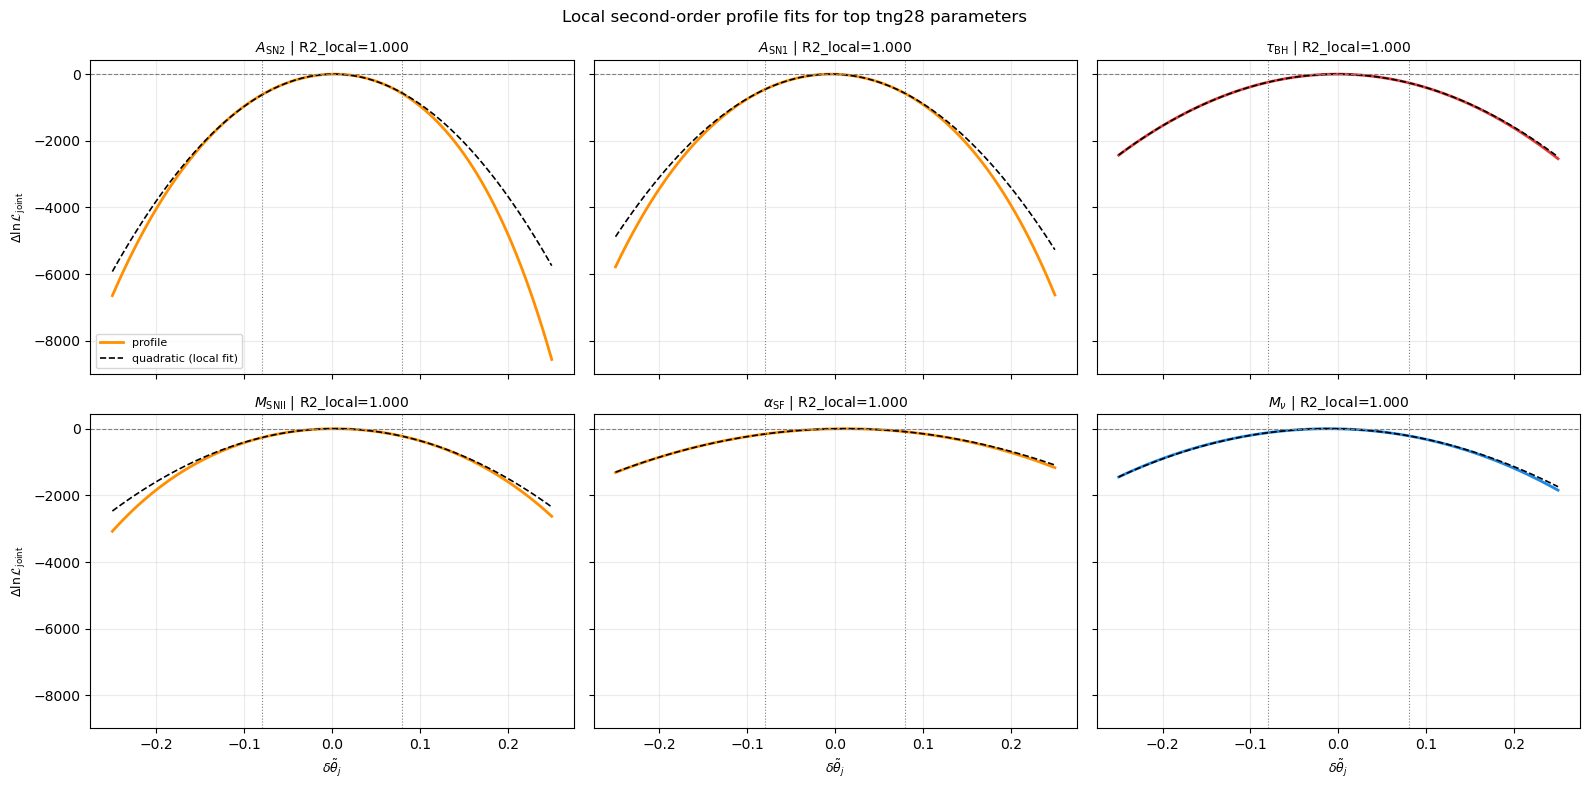

--- Local quadratic correction summary ---
param_idx  label                  a        b        c      R2_local  sigma_quad
       4  $A_{\rm SN2}$          -9.3352e+04 +3.5345e+02 +8.7975e-01   1.000     0.0024
       2  $A_{\rm SN1}$          -8.1151e+04 -7.8279e+02 -7.6858e-01   1.000     0.0004
      25  $\tau_{\rm BH}$        -3.9258e+04 -1.1285e+02 +1.3667e-02   1.000     0.0025
      15  $M_{\rm SNII}$         -3.8538e+04 +2.4455e+02 +4.1987e-01   1.000     0.0027
      12  $\alpha_{\rm SF}$      -1.9117e+04 +4.2886e+02 -2.4461e+00   1.000     0.0063
      11  $M_\nu$                -2.5455e+04 -5.8615e+02 -3.1460e+00   1.000     0.0062

Saved quadratic-profile artifact: /mnt/home/mlee1/vdm_bind2/analysis_physics_cache/jacobian_inference_artifacts/cv_scatter_quadratic_profile_latest.npz


In [27]:
# Use the tng28 ranking to pick parameters for curvature diagnostics.
TOP_CURV_N = 6
curv_local_span = 0.08
curv_scan = np.linspace(-0.25, 0.25, 101)

if 'PROJ' not in globals():
    raise RuntimeError('Run the projection cell first (cell 39).')

idx_tng = PROJ['tng28']['idx']
rank_tng = PROJ['tng28']['rank']
top_idx_global = [int(idx_tng[r]) for r in rank_tng[:TOP_CURV_N]]

curve_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax_i, j in enumerate(top_idx_global):
    delta = np.zeros(N_PARAMS, dtype=np.float64)
    ll = []
    for t in curv_scan:
        delta[:] = 0.0
        delta[j] = t
        ll.append(joint_loglike(delta))
    ll = np.asarray(ll, dtype=np.float64)
    dll = ll - np.nanmax(ll)

    loc = np.abs(curv_scan) <= curv_local_span
    coef = np.polyfit(curv_scan[loc], dll[loc], 2)  # a, b, c
    fit_local = np.polyval(coef, curv_scan)

    # Goodness of fit in local window.
    y_true = dll[loc]
    y_fit = fit_local[loc]
    ss_res = float(np.sum((y_true - y_fit) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2_loc = 1.0 - ss_res / (ss_tot + 1e-12)

    # 1-sigma half-width from quadratic approximation near zero, if concave.
    a, b, c = coef
    sigma_quad = np.nan
    if a < 0:
        roots = np.roots([a, b, c + 0.5])  # solve quadratic = -0.5
        roots = roots[np.isreal(roots)].real
        if len(roots) >= 1:
            sigma_quad = float(np.min(np.abs(roots)))

    curve_rows.append((j, a, b, c, r2_loc, sigma_quad))

    ax = axes[ax_i]
    ax.plot(curv_scan, dll, color=GROUP_COLORS[PARAM_GROUP[j]], lw=2, label='profile')
    ax.plot(curv_scan, fit_local, 'k--', lw=1.2, label='quadratic (local fit)')
    ax.axhline(-0.5, color='gray', ls='--', lw=0.8)
    ax.axvline(-curv_local_span, color='gray', ls=':', lw=0.8)
    ax.axvline(+curv_local_span, color='gray', ls=':', lw=0.8)
    ax.set_title(f"{PRETTY.get(j, str(j))} | R2_local={r2_loc:.3f}", fontsize=10)
    ax.grid(alpha=0.25)
    if ax_i % 3 == 0:
        ax.set_ylabel(r'$\Delta \ln \mathcal{L}_{\rm joint}$', fontsize=9)
    if ax_i >= 3:
        ax.set_xlabel(r'$\delta\tilde\theta_j$', fontsize=9)
    if ax_i == 0:
        ax.legend(fontsize=8)

fig.suptitle('Local second-order profile fits for top tng28 parameters', fontsize=12)
plt.tight_layout()
plt.show()

print('--- Local quadratic correction summary ---')
print('param_idx  label                  a        b        c      R2_local  sigma_quad')
for j, a, b, c, r2_loc, sigma_quad in curve_rows:
    print(
        f"{j:8d}  {PRETTY.get(j, str(j)):22s} "
        f"{a:+.4e} {b:+.4e} {c:+.4e}   {r2_loc:.3f}     {sigma_quad:.4f}"
    )

# Save second-order profile diagnostics.
curv_path = OUT_DIR / 'cv_scatter_quadratic_profile_latest.npz'
np.savez(
    curv_path,
    top_idx_global=np.array(top_idx_global, dtype=int),
    scan=curv_scan,
    local_span=np.array([curv_local_span], dtype=np.float64),
    coef=np.array([[a, b, c] for _, a, b, c, _, _ in curve_rows], dtype=np.float64),
    r2_local=np.array([r2 for _, _, _, _, r2, _ in curve_rows], dtype=np.float64),
    sigma_quad=np.array([sq for _, _, _, _, _, sq in curve_rows], dtype=np.float64),
)
print(f"\nSaved quadratic-profile artifact: {curv_path}")